In [6]:
# Enhanced dataset with 10 news articles
sample_data = [
    {
        "text": "The Federal Reserve announced a 0.25% interest rate hike today, bringing the federal funds rate to 5.25%. This decision comes amid ongoing concerns about inflation, which has remained above the Fed's 2% target for several months. Fed Chair Jerome Powell stated that the central bank will continue to monitor economic data closely and adjust monetary policy as needed. The rate hike is expected to impact mortgage rates, credit card rates, and other consumer lending products. Financial markets showed mixed reactions to the announcement, with banking stocks rising while technology stocks declined. Economists predict that additional rate increases may be necessary if inflation continues to persist at current levels.",
        "summary": "Fed raises interest rates by 0.25% to 5.25% to combat inflation above 2% target."
    },
    {
        "text": "Apple Inc. unveiled its latest iPhone 15 series at the annual September event, featuring significant improvements in camera technology, battery life, and processing power. The new phones include a 48-megapixel main camera with advanced computational photography capabilities, allowing users to capture professional-quality images and videos. The A17 Pro chip delivers 20% faster performance while consuming 15% less power than its predecessor. Apple also announced that all iPhone 15 models will feature USB-C connectivity, marking a departure from the proprietary Lightning connector. The company emphasized its commitment to environmental sustainability, with the new phones made from 75% recycled materials. Pre-orders begin next Friday, with general availability starting September 22nd.",
        "summary": "Apple launches iPhone 15 with improved camera, A17 Pro chip, and USB-C connectivity."
    },
    {
        "text": "Climate scientists report that global temperatures have reached unprecedented levels this summer, with several regions experiencing record-breaking heatwaves. The European Space Agency's Copernicus Climate Change Service confirmed that July 2023 was the hottest month ever recorded globally. Rising sea levels, melting ice caps, and extreme weather events continue to accelerate, prompting urgent calls for immediate action on climate change. The United Nations Secretary-General emphasized that the world is entering an era of 'global boiling' and stressed the need for rapid decarbonization. Renewable energy installations have increased by 40% this year, but experts warn that current efforts are insufficient to meet the Paris Agreement goals. Governments worldwide are under pressure to implement more aggressive climate policies.",
        "summary": "July 2023 sets global temperature record, highlighting urgent need for climate action."
    },
    {
        "text": "SpaceX successfully launched its Starship rocket on its third test flight, marking a significant milestone in the company's ambitious Mars colonization program. The massive rocket, standing 120 meters tall, performed better than previous attempts, reaching an altitude of 234 kilometers before executing a planned splashdown in the Indian Ocean. Elon Musk praised the team's efforts and announced that the next test flight will attempt orbital refueling, a critical capability for deep space missions. NASA has contracted SpaceX to develop a lunar version of Starship for the Artemis program, which aims to return humans to the Moon by 2026. The successful flight brings humanity one step closer to becoming a multi-planetary species, according to Musk's vision.",
        "summary": "SpaceX's Starship completes successful third test flight, advancing Mars colonization goals."
    },
    {
        "text": "Microsoft announced a major breakthrough in quantum computing with the development of a new quantum processor that can maintain stable qubits for extended periods. The company's Azure Quantum platform now offers improved error correction capabilities, making quantum computers more practical for real-world applications. Researchers demonstrated the system's ability to solve complex optimization problems that would take classical computers thousands of years to complete. The quantum processor uses a novel approach called topological qubits, which are more resistant to environmental interference. Microsoft plans to make this technology available to enterprise customers through its cloud services, potentially revolutionizing industries such as pharmaceuticals, finance, and logistics.",
        "summary": "Microsoft develops stable quantum processor with improved error correction for practical applications."
    },
    {
        "text": "The World Health Organization declared the end of the COVID-19 public health emergency, marking a significant turning point in the global pandemic response. While the virus continues to circulate and cause illness, WHO Director-General Tedros Adhanom Ghebreyesus stated that COVID-19 is now at manageable levels and can be treated as an endemic disease. The declaration comes after more than three years of global disruption, during which the pandemic claimed over 7 million lives worldwide. Countries are now transitioning from emergency response to long-term management strategies, including updated vaccination programs and surveillance systems. Health experts emphasize that vigilance remains crucial as new variants may emerge.",
        "summary": "WHO ends COVID-19 public health emergency, transitioning to endemic management approach."
    },
    {
        "text": "Amazon Web Services launched a new artificial intelligence service called Amazon Bedrock, designed to help businesses build and deploy generative AI applications. The platform provides access to foundation models from leading AI companies including Anthropic, AI21 Labs, and Stability AI. Customers can fine-tune these models using their own data while maintaining privacy and security. AWS CEO Andy Jassy emphasized that Bedrock democratizes AI by making advanced capabilities accessible to organizations of all sizes. The service includes tools for responsible AI development, including bias detection and content filtering. Early adopters report significant improvements in customer service automation and content generation workflows.",
        "summary": "AWS introduces Bedrock platform for building generative AI applications with foundation models."
    },
    {
        "text": "Tesla reported record quarterly deliveries of 466,140 vehicles in Q2 2023, exceeding analyst expectations despite ongoing supply chain challenges. The company's Model Y became the world's best-selling electric vehicle, with strong demand in both North American and European markets. Tesla's energy storage business also showed remarkable growth, with Megapack installations increasing by 222% year-over-year. CEO Elon Musk attributed the success to improved manufacturing efficiency and the global expansion of the Supercharger network. The company announced plans to open its charging infrastructure to other electric vehicle manufacturers, potentially accelerating EV adoption industry-wide. Tesla's stock price surged 7% following the delivery announcement.",
        "summary": "Tesla achieves record Q2 deliveries of 466,140 vehicles, led by Model Y success."
    },
    {
        "text": "The European Union reached a landmark agreement on the AI Act, establishing the world's first comprehensive legal framework for artificial intelligence regulation. The legislation categorizes AI systems based on risk levels and imposes strict requirements for high-risk applications in sectors such as healthcare, education, and law enforcement. Companies developing AI systems must ensure transparency, accuracy, and human oversight. The Act includes provisions for protecting fundamental rights and prohibits certain AI practices deemed harmful to society. EU officials believe this framework will set a global standard for AI governance while fostering innovation in the region. The legislation is expected to take effect in 2025 after final approval by member states.",
        "summary": "EU agrees on AI Act, creating world's first comprehensive artificial intelligence regulation framework."
    },
    {
        "text": "Netflix announced a significant shift in its content strategy, investing $17 billion in original programming for 2024 while reducing its reliance on licensed content. The streaming giant plans to produce more international content to capture growing global audiences, with particular focus on Asian and Latin American markets. Co-CEO Ted Sarandos revealed that subscriber growth has accelerated following the introduction of ad-supported tiers and password sharing restrictions. The company is also expanding into gaming, with plans to launch 40 new titles this year. Netflix's stock reached a new all-time high as investors responded positively to the strategic pivot and improved subscriber metrics.",
        "summary": "Netflix invests $17B in original content for 2024, focusing on international markets and gaming."
    }
]

print(f"Dataset created with {len(sample_data)} articles")


Dataset created with 10 articles


In [7]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter
import pickle
import os

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, backend as K
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model

# Additional utilities
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# GPU configuration
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print(f"GPU available: {physical_devices[0]}")
else:
    print("GPU not available, using CPU")

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create output directories
os.makedirs('attention_results', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('visualizations', exist_ok=True)
print("Output directories created!")


GPU not available, using CPU
Libraries imported successfully!
TensorFlow version: 2.19.0
Keras version: 3.9.2
Output directories created!


In [8]:

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter
import pickle
import os

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, backend as K
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model

# Additional utilities
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# GPU configuration
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print(f"GPU available: {physical_devices[0]}")
else:
    print("GPU not available, using CPU")

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create output directories
os.makedirs('attention_results', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('visualizations', exist_ok=True)
print("Output directories created!")


GPU not available, using CPU
Libraries imported successfully!
TensorFlow version: 2.19.0
Keras version: 3.9.2
Output directories created!


In [9]:
class AttentionTextPreprocessor:
    """
    Enhanced text preprocessor for attention-based models
    """
    def __init__(self, max_text_length=120, max_summary_length=25, vocab_size=8000):
        self.max_text_length = max_text_length
        self.max_summary_length = max_summary_length
        self.vocab_size = vocab_size
        
        # Special tokens
        self.START_TOKEN = '<START>'
        self.END_TOKEN = '<END>'
        self.PAD_TOKEN = '<PAD>'
        self.UNK_TOKEN = '<UNK>'
        
        # Tokenizers
        self.text_tokenizer = None
        self.summary_tokenizer = None
        
        # Vocabulary mappings
        self.word_to_idx = {}
        self.idx_to_word = {}
        
    def clean_text(self, text):
        """Enhanced text cleaning preserving important punctuation"""
        # Convert to lowercase
        text = text.lower()
        
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text)
        
        # Keep important punctuation for attention alignment
        text = re.sub(r'[^\w\s.,!?;:\-\']', '', text)
        
        # Remove multiple punctuation
        text = re.sub(r'[.,!?;:]+', lambda m: m.group(0)[0], text)
        
        return text.strip()
    
    def prepare_data(self, data):
        """Prepare and clean the dataset"""
        texts = []
        summaries = []
        
        for item in data:
            # Clean text and summary
            clean_text = self.clean_text(item['text'])
            clean_summary = self.clean_text(item['summary'])
            
            # Add special tokens to summary
            clean_summary = f"{self.START_TOKEN} {clean_summary} {self.END_TOKEN}"
            
            texts.append(clean_text)
            summaries.append(clean_summary)
        
        return texts, summaries
    
    def create_tokenizer(self, texts, vocab_size):
        """Create and fit tokenizer"""
        tokenizer = Tokenizer(
            num_words=vocab_size,
            oov_token=self.UNK_TOKEN,
            filters='',
            lower=True
        )
        tokenizer.fit_on_texts(texts)
        return tokenizer
    
    def fit(self, data):
        """Fit the preprocessor on the data"""
        # Prepare data
        texts, summaries = self.prepare_data(data)
        
        # Create tokenizers
        self.text_tokenizer = self.create_tokenizer(texts, self.vocab_size)
        self.summary_tokenizer = self.create_tokenizer(summaries, self.vocab_size)
        
        # Create word mappings
        self.word_to_idx = self.text_tokenizer.word_index
        self.idx_to_word = {idx: word for word, idx in self.word_to_idx.items()}
        
        print(f"Text vocabulary size: {len(self.text_tokenizer.word_index)}")
        print(f"Summary vocabulary size: {len(self.summary_tokenizer.word_index)}")
        
        return self
    
    def transform(self, data):
        """Transform the data to sequences"""
        # Prepare data
        texts, summaries = self.prepare_data(data)
        
        # Convert to sequences
        text_sequences = self.text_tokenizer.texts_to_sequences(texts)
        summary_sequences = self.summary_tokenizer.texts_to_sequences(summaries)
        
        # Pad sequences
        text_padded = pad_sequences(
            text_sequences, 
            maxlen=self.max_text_length, 
            padding='post',
            truncating='post'
        )
        
        summary_padded = pad_sequences(
            summary_sequences, 
            maxlen=self.max_summary_length, 
            padding='post',
            truncating='post'
        )
        
        # Create decoder input (shifted right) and target (shifted left)
        decoder_input = summary_padded[:, :-1]
        decoder_target = summary_padded[:, 1:]
        
        return {
            'encoder_input': text_padded,
            'decoder_input': decoder_input,
            'decoder_target': decoder_target,
            'original_texts': texts,
            'original_summaries': summaries
        }
    
    def fit_transform(self, data):
        """Fit and transform in one step"""
        return self.fit(data).transform(data)
    
    def decode_sequence(self, sequence, tokenizer_type='text'):
        """Decode a sequence back to text"""
        tokenizer = self.text_tokenizer if tokenizer_type == 'text' else self.summary_tokenizer
        
        # Get reverse word index
        reverse_word_index = {idx: word for word, idx in tokenizer.word_index.items()}
        
        # Decode sequence
        words = []
        for idx in sequence:
            if idx == 0:  # Padding
                break
            word = reverse_word_index.get(idx, self.UNK_TOKEN)
            if word not in [self.START_TOKEN, self.END_TOKEN, self.PAD_TOKEN]:
                words.append(word)
        
        return ' '.join(words)
    
    def get_vocab_size(self, tokenizer_type='text'):
        """Get vocabulary size"""
        tokenizer = self.text_tokenizer if tokenizer_type == 'text' else self.summary_tokenizer
        return len(tokenizer.word_index) + 1  # +1 for padding token

# Initialize preprocessor
preprocessor = AttentionTextPreprocessor(
    max_text_length=120,
    max_summary_length=25,
    vocab_size=8000
)

# Fit and transform data
processed_data = preprocessor.fit_transform(sample_data)

print("Data preprocessing completed!")
print(f"Encoder input shape: {processed_data['encoder_input'].shape}")
print(f"Decoder input shape: {processed_data['decoder_input'].shape}")
print(f"Decoder target shape: {processed_data['decoder_target'].shape}")
print(f"Text vocabulary size: {preprocessor.get_vocab_size('text')}")
print(f"Summary vocabulary size: {preprocessor.get_vocab_size('summary')}")

# Save preprocessor
with open('models/attention_preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("Preprocessor saved!")


Text vocabulary size: 661
Summary vocabulary size: 116
Data preprocessing completed!
Encoder input shape: (10, 120)
Decoder input shape: (10, 24)
Decoder target shape: (10, 24)
Text vocabulary size: 662
Summary vocabulary size: 117
Preprocessor saved!


In [10]:
# Bahdanau (Additive) Attention Mechanism
class BahdanauAttention(layers.Layer):
    """
    Bahdanau attention mechanism (additive attention)
    """
    def __init__(self, units, **kwargs):
        super(BahdanauAttention, self).__init__(**kwargs)
        self.units = units
        
    def build(self, input_shape):
        # Weight matrices
        self.W_s = self.add_weight(
            name='W_s',
            shape=(input_shape[0][-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.W_h = self.add_weight(
            name='W_h',
            shape=(input_shape[1][-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.V = self.add_weight(
            name='V',
            shape=(self.units, 1),
            initializer='glorot_uniform',
            trainable=True
        )
        super(BahdanauAttention, self).build(input_shape)
        
    def call(self, inputs):
        # inputs: [encoder_outputs, decoder_state]
        encoder_outputs, decoder_state = inputs
        
        # Expand decoder state to match encoder sequence length
        decoder_state_expanded = K.expand_dims(decoder_state, axis=1)
        decoder_state_tiled = K.tile(decoder_state_expanded, [1, K.shape(encoder_outputs)[1], 1])
        
        # Compute attention scores
        score = K.tanh(
            K.dot(encoder_outputs, self.W_s) + 
            K.dot(decoder_state_tiled, self.W_h)
        )
        
        # Compute attention weights
        attention_weights = K.softmax(K.dot(score, self.V), axis=1)
        
        # Compute context vector
        context_vector = K.sum(attention_weights * encoder_outputs, axis=1)
        
        return context_vector, attention_weights
    
    def compute_output_shape(self, input_shape):
        return [(input_shape[0][0], input_shape[0][2]), (input_shape[0][0], input_shape[0][1], 1)]

# Luong (Multiplicative) Attention Mechanism
class LuongAttention(layers.Layer):
    """
    Luong attention mechanism (multiplicative attention)
    """
    def __init__(self, units, attention_type='general', **kwargs):
        super(LuongAttention, self).__init__(**kwargs)
        self.units = units
        self.attention_type = attention_type
        
    def build(self, input_shape):
        if self.attention_type == 'general':
            self.W_a = self.add_weight(
                name='W_a',
                shape=(input_shape[1][-1], input_shape[0][-1]),
                initializer='glorot_uniform',
                trainable=True
            )
        elif self.attention_type == 'concat':
            self.W_a = self.add_weight(
                name='W_a',
                shape=(input_shape[0][-1] + input_shape[1][-1], self.units),
                initializer='glorot_uniform',
                trainable=True
            )
            self.V_a = self.add_weight(
                name='V_a',
                shape=(self.units, 1),
                initializer='glorot_uniform',
                trainable=True
            )
        
        super(LuongAttention, self).build(input_shape)
        
    def call(self, inputs):
        # inputs: [encoder_outputs, decoder_state]
        encoder_outputs, decoder_state = inputs
        
        if self.attention_type == 'dot':
            # Dot-product attention
            scores = K.batch_dot(encoder_outputs, K.expand_dims(decoder_state, axis=2))
            scores = K.squeeze(scores, axis=2)
            
        elif self.attention_type == 'general':
            # General attention
            transformed_state = K.dot(decoder_state, self.W_a)
            scores = K.batch_dot(encoder_outputs, K.expand_dims(transformed_state, axis=2))
            scores = K.squeeze(scores, axis=2)
            
        elif self.attention_type == 'concat':
            # Concat attention
            decoder_state_expanded = K.expand_dims(decoder_state, axis=1)
            decoder_state_tiled = K.tile(decoder_state_expanded, [1, K.shape(encoder_outputs)[1], 1])
            
            concatenated = K.concatenate([encoder_outputs, decoder_state_tiled], axis=2)
            scores = K.tanh(K.dot(concatenated, self.W_a))
            scores = K.dot(scores, self.V_a)
            scores = K.squeeze(scores, axis=2)
        
        # Compute attention weights
        attention_weights = K.softmax(scores, axis=1)
        
        # Compute context vector
        context_vector = K.sum(K.expand_dims(attention_weights, axis=2) * encoder_outputs, axis=1)
        
        return context_vector, attention_weights
    
    def compute_output_shape(self, input_shape):
        return [(input_shape[0][0], input_shape[0][2]), (input_shape[0][0], input_shape[0][1])]

print("Attention mechanisms defined successfully!")


Attention mechanisms defined successfully!


In [11]:
# Attention-Enhanced Seq2Seq Model
class AttentionSeq2SeqModel:
    """
    Seq2Seq model with attention mechanisms for text summarization
    """
    def __init__(self, vocab_size_input, vocab_size_output, embedding_dim=128, 
                 encoder_units=256, decoder_units=512, attention_type='bahdanau'):
        self.vocab_size_input = vocab_size_input
        self.vocab_size_output = vocab_size_output
        self.embedding_dim = embedding_dim
        self.encoder_units = encoder_units
        self.decoder_units = decoder_units
        self.attention_type = attention_type
        
        # Model components
        self.encoder = None
        self.decoder = None
        self.model = None
        
        # Inference models
        self.encoder_model = None
        self.decoder_model = None
        
    def build_encoder(self, input_length):
        """Build encoder with bidirectional LSTM"""
        # Input layer
        encoder_input = layers.Input(shape=(input_length,), name='encoder_input')
        
        # Embedding layer
        encoder_embedding = layers.Embedding(
            self.vocab_size_input, 
            self.embedding_dim,
            mask_zero=True,
            name='encoder_embedding'
        )(encoder_input)
        
        # Bidirectional LSTM
        encoder_lstm = layers.Bidirectional(
            layers.LSTM(self.encoder_units, return_sequences=True, return_state=True, dropout=0.2),
            name='encoder_lstm'
        )(encoder_embedding)
        
        # Extract outputs and states
        encoder_outputs = encoder_lstm[0]
        forward_h, forward_c, backward_h, backward_c = encoder_lstm[1:]
        
        # Combine bidirectional states
        encoder_h = layers.Concatenate()([forward_h, backward_h])
        encoder_c = layers.Concatenate()([forward_c, backward_c])
        
        return encoder_input, encoder_outputs, encoder_h, encoder_c
    
    def build_decoder(self, encoder_outputs, encoder_h, encoder_c, output_length):
        """Build decoder with attention mechanism"""
        # Decoder input
        decoder_input = layers.Input(shape=(output_length,), name='decoder_input')
        
        # Embedding layer
        decoder_embedding_layer = layers.Embedding(
            self.vocab_size_output,
            self.embedding_dim,
            mask_zero=True,
            name='decoder_embedding'
        )
        decoder_embedding = decoder_embedding_layer(decoder_input)
        
        # LSTM layer
        decoder_lstm = layers.LSTM(
            self.decoder_units,
            return_sequences=True,
            return_state=True,
            dropout=0.2,
            name='decoder_lstm'
        )
        
        # Initialize decoder state with encoder state
        decoder_outputs, decoder_h, decoder_c = decoder_lstm(
            decoder_embedding,
            initial_state=[encoder_h, encoder_c]
        )
        
        # Attention mechanism
        if self.attention_type == 'bahdanau':
            attention_layer = BahdanauAttention(self.decoder_units)
        elif self.attention_type == 'luong':
            attention_layer = LuongAttention(self.decoder_units, 'general')
        else:
            raise ValueError(f"Unknown attention type: {self.attention_type}")
        
        # Apply attention to each time step
        context_vectors = []
        attention_weights_list = []
        
        for i in range(output_length):
            # Get decoder state at time step i
            decoder_state_i = decoder_outputs[:, i, :]
            
            # Compute attention
            context_vector, attention_weights = attention_layer([encoder_outputs, decoder_state_i])
            
            context_vectors.append(context_vector)
            attention_weights_list.append(attention_weights)
        
        # Stack context vectors
        context_vectors = layers.Lambda(lambda x: K.stack(x, axis=1))(context_vectors)
        
        # Concatenate decoder outputs with context vectors
        decoder_concat = layers.Concatenate(axis=-1)([decoder_outputs, context_vectors])
        
        # Dense layer for output
        decoder_dense = layers.Dense(
            self.vocab_size_output,
            activation='softmax',
            name='decoder_dense'
        )
        
        decoder_output = decoder_dense(decoder_concat)
        
        return decoder_input, decoder_output, decoder_embedding_layer, decoder_lstm, decoder_dense, attention_layer
    
    def build_model(self, input_length, output_length):
        """Build complete Seq2Seq model with attention"""
        # Build encoder
        encoder_input, encoder_outputs, encoder_h, encoder_c = self.build_encoder(input_length)
        
        # Build decoder
        decoder_input, decoder_output, decoder_embedding_layer, decoder_lstm, decoder_dense, attention_layer = self.build_decoder(
            encoder_outputs, encoder_h, encoder_c, output_length
        )
        
        # Create model
        self.model = models.Model([encoder_input, decoder_input], decoder_output)
        
        # Store components for inference
        self.encoder_input = encoder_input
        self.encoder_outputs = encoder_outputs
        self.encoder_h = encoder_h
        self.encoder_c = encoder_c
        self.decoder_input = decoder_input
        self.decoder_embedding_layer = decoder_embedding_layer
        self.decoder_lstm = decoder_lstm
        self.decoder_dense = decoder_dense
        self.attention_layer = attention_layer
        
        return self.model
    
    def build_inference_models(self):
        """Build separate encoder and decoder models for inference"""
        # Encoder model
        self.encoder_model = models.Model(
            self.encoder_input,
            [self.encoder_outputs, self.encoder_h, self.encoder_c]
        )
        
        # Decoder model inputs
        decoder_state_input_h = layers.Input(shape=(self.decoder_units,), name='decoder_state_input_h')
        decoder_state_input_c = layers.Input(shape=(self.decoder_units,), name='decoder_state_input_c')
        encoder_outputs_input = layers.Input(shape=(None, self.encoder_units * 2), name='encoder_outputs_input')
        
        # Single time step input
        decoder_input_single = layers.Input(shape=(1,), name='decoder_input_single')
        
        # Embedding
        decoder_embedding_single = self.decoder_embedding_layer(decoder_input_single)
        
        # LSTM
        decoder_outputs_single, decoder_h_single, decoder_c_single = self.decoder_lstm(
            decoder_embedding_single,
            initial_state=[decoder_state_input_h, decoder_state_input_c]
        )
        
        # Attention
        decoder_state_single = decoder_outputs_single[:, 0, :]
        context_vector_single, attention_weights_single = self.attention_layer(
            [encoder_outputs_input, decoder_state_single]
        )
        
        # Concatenate
        decoder_concat_single = layers.Concatenate(axis=-1)(
            [decoder_outputs_single[:, 0, :], context_vector_single]
        )
        
        # Dense layer
        decoder_output_single = self.decoder_dense(decoder_concat_single)
        
        # Decoder model
        self.decoder_model = models.Model(
            [decoder_input_single, decoder_state_input_h, decoder_state_input_c, encoder_outputs_input],
            [decoder_output_single, decoder_h_single, decoder_c_single, attention_weights_single]
        )
        
        return self.encoder_model, self.decoder_model
    
    def compile_model(self, optimizer='adam', loss='sparse_categorical_crossentropy'):
        """Compile the model"""
        self.model.compile(
            optimizer=optimizer,
            loss=loss,
            metrics=['accuracy']
        )
        
        return self.model
    
    def summary(self):
        """Display model summary"""
        if self.model:
            self.model.summary()
        else:
            print("Model not built yet. Call build_model() first.")
            
    def save_model(self, filepath):
        """Save the model"""
        if self.model:
            self.model.save(filepath)
        else:
            print("Model not built yet. Call build_model() first.")
    
    def load_model(self, filepath):
        """Load a saved model"""
        self.model = models.load_model(filepath)
        return self.model

print("Attention Seq2Seq model class defined successfully!")

Attention Seq2Seq model class defined successfully!


In [12]:
# Attention Text Summarizer with Visualization
class AttentionTextSummarizer:
    """
    Text summarizer with attention mechanisms and visualization capabilities
    """
    def __init__(self, preprocessor, model, encoder_model, decoder_model):
        self.preprocessor = preprocessor
        self.model = model
        self.encoder_model = encoder_model
        self.decoder_model = decoder_model
        
        # Get special tokens
        self.start_token = self.preprocessor.summary_tokenizer.word_index.get('<START>', 1)
        self.end_token = self.preprocessor.summary_tokenizer.word_index.get('<END>', 2)
        
    def summarize_text(self, text, max_length=None, return_attention=False):
        """
        Generate summary with attention tracking
        """
        if max_length is None:
            max_length = self.preprocessor.max_summary_length
        
        # Preprocess input text
        processed = self.preprocessor.transform([{'text': text, 'summary': ''}])
        input_seq = processed['encoder_input']
        
        # Get encoder outputs
        encoder_outputs, encoder_h, encoder_c = self.encoder_model.predict(input_seq, verbose=0)
        
        # Initialize decoder state
        decoder_state_h = encoder_h
        decoder_state_c = encoder_c
        
        # Initialize decoder input
        decoder_input = np.array([[self.start_token]])
        
        # Store results
        generated_summary = []
        attention_weights = []
        
        # Generate summary word by word
        for i in range(max_length):
            # Get decoder prediction
            decoder_output, decoder_h, decoder_c, attention_weight = self.decoder_model.predict(
                [decoder_input, decoder_state_h, decoder_state_c, encoder_outputs], 
                verbose=0
            )
            
            # Get predicted word
            predicted_word_idx = np.argmax(decoder_output[0, :])
            
            # Stop if end token
            if predicted_word_idx == self.end_token:
                break
            
            # Add to summary
            generated_summary.append(predicted_word_idx)
            
            # Store attention weights
            if return_attention:
                attention_weights.append(attention_weight[0])
            
            # Update decoder input and state
            decoder_input = np.array([[predicted_word_idx]])
            decoder_state_h = decoder_h
            decoder_state_c = decoder_c
        
        # Decode summary
        summary = self.preprocessor.decode_sequence(generated_summary, 'summary')
        
        if return_attention:
            return summary, attention_weights
        else:
            return summary
    
    def batch_summarize(self, texts, max_length=None):
        """
        Generate summaries for multiple texts
        """
        summaries = []
        for text in texts:
            summary = self.summarize_text(text, max_length)
            summaries.append(summary)
        return summaries
    
    def visualize_attention(self, text, summary=None, figsize=(12, 8)):
        """
        Visualize attention weights as heatmap
        """
        if summary is None:
            summary, attention_weights = self.summarize_text(text, return_attention=True)
        else:
            _, attention_weights = self.summarize_text(text, return_attention=True)
        
        # Get input tokens
        processed = self.preprocessor.transform([{'text': text, 'summary': ''}])
        input_tokens = self.preprocessor.decode_sequence(processed['encoder_input'][0], 'text').split()
        
        # Get output tokens
        output_tokens = summary.split()
        
        if not attention_weights or not output_tokens:
            print("No attention weights or output tokens to visualize")
            return
        
        # Create attention matrix
        attention_matrix = np.zeros((len(output_tokens), len(input_tokens)))
        
        for i, attention_weight in enumerate(attention_weights):
            if i < len(output_tokens):
                # Ensure attention weight matches input length
                attention_length = min(len(attention_weight), len(input_tokens))
                attention_matrix[i, :attention_length] = attention_weight[:attention_length]
        
        # Create visualization
        plt.figure(figsize=figsize)
        sns.heatmap(
            attention_matrix,
            xticklabels=input_tokens,
            yticklabels=output_tokens,
            cmap='Blues',
            annot=False,
            fmt='.2f'
        )
        
        plt.title('Attention Weights Heatmap')
        plt.xlabel('Input Tokens')
        plt.ylabel('Output Tokens')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        return attention_matrix
    
    def analyze_attention(self, text, summary=None):
        """
        Analyze attention patterns
        """
        if summary is None:
            summary, attention_weights = self.summarize_text(text, return_attention=True)
        else:
            _, attention_weights = self.summarize_text(text, return_attention=True)
        
        if not attention_weights:
            return None
        
        # Convert attention weights to numpy array
        attention_array = np.array(attention_weights)
        
        # Calculate attention statistics
        stats = {
            'mean_attention': np.mean(attention_array),
            'max_attention': np.max(attention_array),
            'min_attention': np.min(attention_array),
            'attention_entropy': self._calculate_entropy(attention_array),
            'attention_concentration': self._calculate_concentration(attention_array)
        }
        
        return stats
    
    def _calculate_entropy(self, attention_weights):
        """Calculate entropy of attention distribution"""
        entropy_values = []
        for weights in attention_weights:
            # Normalize weights
            weights = weights / np.sum(weights)
            # Calculate entropy
            entropy = -np.sum(weights * np.log(weights + 1e-10))
            entropy_values.append(entropy)
        return np.mean(entropy_values)
    
    def _calculate_concentration(self, attention_weights):
        """Calculate attention concentration (inverse of entropy)"""
        concentration_values = []
        for weights in attention_weights:
            # Calculate max weight proportion
            max_weight = np.max(weights)
            total_weight = np.sum(weights)
            concentration = max_weight / total_weight
            concentration_values.append(concentration)
        return np.mean(concentration_values)

print("Attention Text Summarizer defined successfully!")


Attention Text Summarizer defined successfully!


In [13]:
# Enhanced Evaluation Metrics
class AttentionEvaluator:
    """
    Evaluation metrics for attention-based text summarization
    """
    def __init__(self):
        pass
    
    def calculate_rouge_1(self, reference, candidate):
        """Calculate ROUGE-1 score"""
        ref_words = set(reference.lower().split())
        cand_words = set(candidate.lower().split())
        
        if len(ref_words) == 0:
            return 0.0
        
        overlap = len(ref_words.intersection(cand_words))
        precision = overlap / len(cand_words) if len(cand_words) > 0 else 0
        recall = overlap / len(ref_words)
        
        if precision + recall == 0:
            return 0.0
        
        f1 = 2 * precision * recall / (precision + recall)
        return f1
    
    def calculate_rouge_2(self, reference, candidate):
        """Calculate ROUGE-2 score (bigram overlap)"""
        ref_bigrams = self._get_bigrams(reference.lower().split())
        cand_bigrams = self._get_bigrams(candidate.lower().split())
        
        if len(ref_bigrams) == 0:
            return 0.0
        
        overlap = len(ref_bigrams.intersection(cand_bigrams))
        precision = overlap / len(cand_bigrams) if len(cand_bigrams) > 0 else 0
        recall = overlap / len(ref_bigrams)
        
        if precision + recall == 0:
            return 0.0
        
        f1 = 2 * precision * recall / (precision + recall)
        return f1
    
    def calculate_rouge_l(self, reference, candidate):
        """Calculate ROUGE-L score (longest common subsequence)"""
        ref_words = reference.lower().split()
        cand_words = candidate.lower().split()
        
        lcs_length = self._lcs_length(ref_words, cand_words)
        
        if len(ref_words) == 0 or len(cand_words) == 0:
            return 0.0
        
        precision = lcs_length / len(cand_words)
        recall = lcs_length / len(ref_words)
        
        if precision + recall == 0:
            return 0.0
        
        f1 = 2 * precision * recall / (precision + recall)
        return f1
    
    def calculate_bleu(self, reference, candidate, n=4):
        """Calculate BLEU score"""
        ref_words = reference.lower().split()
        cand_words = candidate.lower().split()
        
        if len(cand_words) == 0:
            return 0.0
        
        # Calculate brevity penalty
        bp = min(1.0, len(cand_words) / len(ref_words)) if len(ref_words) > 0 else 0
        
        # Calculate n-gram precisions
        precisions = []
        for i in range(1, n + 1):
            ref_ngrams = self._get_ngrams(ref_words, i)
            cand_ngrams = self._get_ngrams(cand_words, i)
            
            if len(cand_ngrams) == 0:
                precisions.append(0.0)
            else:
                overlap = len(ref_ngrams.intersection(cand_ngrams))
                precision = overlap / len(cand_ngrams)
                precisions.append(precision)
        
        # Calculate geometric mean
        if all(p > 0 for p in precisions):
            geo_mean = np.exp(np.mean(np.log(precisions)))
            return bp * geo_mean
        else:
            return 0.0
    
    def _get_bigrams(self, words):
        """Get bigrams from word list"""
        bigrams = set()
        for i in range(len(words) - 1):
            bigrams.add((words[i], words[i + 1]))
        return bigrams
    
    def _get_ngrams(self, words, n):
        """Get n-grams from word list"""
        ngrams = set()
        for i in range(len(words) - n + 1):
            ngrams.add(tuple(words[i:i + n]))
        return ngrams
    
    def _lcs_length(self, seq1, seq2):
        """Calculate longest common subsequence length"""
        m, n = len(seq1), len(seq2)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if seq1[i - 1] == seq2[j - 1]:
                    dp[i][j] = dp[i - 1][j - 1] + 1
                else:
                    dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
        
        return dp[m][n]
    
    def evaluate_summaries(self, references, candidates):
        """Evaluate multiple summaries"""
        if len(references) != len(candidates):
            raise ValueError("Number of references and candidates must match")
        
        rouge_1_scores = []
        rouge_2_scores = []
        rouge_l_scores = []
        bleu_scores = []
        
        for ref, cand in zip(references, candidates):
            rouge_1_scores.append(self.calculate_rouge_1(ref, cand))
            rouge_2_scores.append(self.calculate_rouge_2(ref, cand))
            rouge_l_scores.append(self.calculate_rouge_l(ref, cand))
            bleu_scores.append(self.calculate_bleu(ref, cand))
        
        results = {
            'rouge_1': {
                'mean': np.mean(rouge_1_scores),
                'std': np.std(rouge_1_scores),
                'scores': rouge_1_scores
            },
            'rouge_2': {
                'mean': np.mean(rouge_2_scores),
                'std': np.std(rouge_2_scores),
                'scores': rouge_2_scores
            },
            'rouge_l': {
                'mean': np.mean(rouge_l_scores),
                'std': np.std(rouge_l_scores),
                'scores': rouge_l_scores
            },
            'bleu': {
                'mean': np.mean(bleu_scores),
                'std': np.std(bleu_scores),
                'scores': bleu_scores
            }
        }
        
        return results
    
    def print_evaluation_results(self, results):
        """Print evaluation results in a formatted way"""
        print("=" * 60)
        print("EVALUATION RESULTS")
        print("=" * 60)
        
        for metric, data in results.items():
            print(f"\n{metric.upper()}:")
            print(f"  Mean: {data['mean']:.4f}")
            print(f"  Std:  {data['std']:.4f}")
        
        print("=" * 60)

# Initialize evaluator
evaluator = AttentionEvaluator()
print("Attention Evaluator initialized successfully!")


Attention Evaluator initialized successfully!


In [14]:
# Model Initialization and Training Setup
print("=" * 60)
print("ATTENTION-ENHANCED SEQ2SEQ MODEL SETUP")
print("=" * 60)

# Initialize model with Bahdanau attention
attention_model = AttentionSeq2SeqModel(
    vocab_size_input=preprocessor.get_vocab_size('text'),
    vocab_size_output=preprocessor.get_vocab_size('summary'),
    embedding_dim=128,
    encoder_units=256,
    decoder_units=512,
    attention_type='bahdanau'
)

# Build the model
model = attention_model.build_model(
    input_length=preprocessor.max_text_length,
    output_length=preprocessor.max_summary_length - 1  # -1 for teacher forcing
)

# Compile the model
model = attention_model.compile_model(
    optimizer='adam',
    loss='sparse_categorical_crossentropy'
)

print(f"Model built successfully!")
print(f"Input vocabulary size: {preprocessor.get_vocab_size('text')}")
print(f"Output vocabulary size: {preprocessor.get_vocab_size('summary')}")
print(f"Model parameters: {model.count_params():,}")

# Display model summary
attention_model.summary()

# Training Configuration
EPOCHS = 60
BATCH_SIZE = 2
VALIDATION_SPLIT = 0.2

# Setup callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='models/best_attention_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        'attention_results/training_log.csv',
        append=True
    )
]

print("\nTraining configuration:")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Validation split: {VALIDATION_SPLIT}")
print(f"Callbacks: {len(callbacks)} configured")

# Prepare training data
X_train = [processed_data['encoder_input'], processed_data['decoder_input']]
y_train = processed_data['decoder_target']

print(f"\nTraining data shapes:")
print(f"Encoder input: {X_train[0].shape}")
print(f"Decoder input: {X_train[1].shape}")
print(f"Decoder target: {y_train.shape}")

# Display sample data
print("\nSample processed data:")
print(f"Original text: {processed_data['original_texts'][0][:100]}...")
print(f"Original summary: {processed_data['original_summaries'][0]}")
print(f"Encoder input (first 10): {X_train[0][0][:10]}")
print(f"Decoder input (first 10): {X_train[1][0][:10]}")
print(f"Decoder target (first 10): {y_train[0][:10]}")

print("\n" + "=" * 60)
print("READY FOR TRAINING!")
print("=" * 60)
print("\nTo start training, run:")
print("history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,")
print("                    validation_split=VALIDATION_SPLIT, callbacks=callbacks)")

print("\nTo build inference models after training, run:")
print("encoder_model, decoder_model = attention_model.build_inference_models()")

print("\nTo create summarizer after training, run:")
print("summarizer = AttentionTextSummarizer(preprocessor, model, encoder_model, decoder_model)")

print("\nTo test summarization, run:")
print("test_text = sample_data[0]['text']")
print("summary = summarizer.summarize_text(test_text)")
print("summarizer.visualize_attention(test_text)")

print("\n" + "=" * 60)
print("NOTEBOOK COMPLETED SUCCESSFULLY!")
print("=" * 60)


ATTENTION-ENHANCED SEQ2SEQ MODEL SETUP

Model built successfully!
Input vocabulary size: 662
Output vocabulary size: 117
Model parameters: 2,845,685


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 120)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 120, 128)  │     84,736 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 120)       │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm        │ [(None, 120,      │    788,480 │ encoder_embeddin… │
│ (Bidirectional)     │ 512), (None,      │            │ not_equal[0][0]   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 24, 128)   │     14,976 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ encoder_lstm[0][… │
│ (Concatenate)       │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512)       │          0 │ encoder_lstm[0][… │
│ (Concatenate)       │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 24, 512), │  1,312,768 │ decoder_embeddin… │
│                     │ (None, 512),      │            │ concatenate[0][0… │
│                     │ (None, 512)]      │            │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 512)       │          0 │ decoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 512)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 512)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 512)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 512)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 512)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,845,685 (10.86 MB)

 Trainable params: 2,845,685 (10.86 MB)

 Non-trainable params: 0 (0.00 B)


Training configuration:
Epochs: 60
Batch size: 2
Validation split: 0.2
Callbacks: 3 configured

Training data shapes:
Encoder input: (10, 120)
Decoder input: (10, 24)
Decoder target: (10, 24)

Sample processed data:
Original text: the federal reserve announced a 0.25 interest rate hike today, bringing the federal funds rate to 5....
Original summary: <START> fed raises interest rates by 0.25 to 5.25 to combat inflation above 2 target. <END>
Encoder input (first 10): [  2  53 134  14   5 135 136  25  54 137]
Decoder input (first 10): [ 2 12 13 14 15  7 16  5 17  5]
Decoder target (first 10): [12 13 14 15  7 16  5 17  5 18]

READY FOR TRAINING!

To start training, run:
history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                    validation_split=VALIDATION_SPLIT, callbacks=callbacks)

To build inference models after training, run:
encoder_model, decoder_model = attention_model.build_inference_models()

To create summarizer after training, run:
summariz

In [15]:
# Ensure preprocessor is available
# If preprocessor doesn't exist, recreate it
try:
    preprocessor.get_vocab_size('text')
    print("Preprocessor is available!")
except NameError:
    print("Preprocessor not found. Creating new preprocessor...")
    
    # Initialize preprocessor
    preprocessor = AttentionTextPreprocessor(
        max_text_length=120,
        max_summary_length=25,
        vocab_size=8000
    )
    
    # Fit and transform data
    processed_data = preprocessor.fit_transform(sample_data)
    
    print("New preprocessor created and fitted!")
    print(f"Encoder input shape: {processed_data['encoder_input'].shape}")
    print(f"Decoder input shape: {processed_data['decoder_input'].shape}")
    print(f"Decoder target shape: {processed_data['decoder_target'].shape}")
    print(f"Text vocabulary size: {preprocessor.get_vocab_size('text')}")
    print(f"Summary vocabulary size: {preprocessor.get_vocab_size('summary')}")
    
    # Save preprocessor
    with open('models/attention_preprocessor.pkl', 'wb') as f:
        pickle.dump(preprocessor, f)
    
    print("Preprocessor saved!")


Preprocessor is available!


In [16]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter
import pickle
import os

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, backend as K
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model

# Custom attention layer
class AttentionLayer(layers.Layer):
    """
    Custom attention layer implementation
    """
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
        
    def build(self, input_shape):
        # Create trainable weights
        self.W_a = self.add_weight(name='W_a',
                                  shape=(input_shape[-1], input_shape[-1]),
                                  initializer='uniform',
                                  trainable=True)
        self.U_a = self.add_weight(name='U_a',
                                  shape=(input_shape[-1], input_shape[-1]),
                                  initializer='uniform',
                                  trainable=True)
        self.V_a = self.add_weight(name='V_a',
                                  shape=(input_shape[-1], 1),
                                  initializer='uniform',
                                  trainable=True)
        super(AttentionLayer, self).build(input_shape)
        
    def call(self, inputs):
        """
        Compute attention weights and context vector
        """
        # inputs: [encoder_outputs, decoder_state]
        encoder_outputs, decoder_state = inputs
        
        # Compute attention scores
        score = tf.nn.tanh(
            K.dot(encoder_outputs, self.W_a) + 
            K.dot(K.expand_dims(decoder_state, 1), self.U_a)
        )
        attention_weights = tf.nn.softmax(K.dot(score, self.V_a), axis=1)
        
        # Compute context vector
        context_vector = attention_weights * encoder_outputs
        context_vector = K.sum(context_vector, axis=1)
        
        return context_vector, attention_weights

# NLP and text processing
import nltk
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')

# Evaluation metrics
from sacrebleu import corpus_bleu

# Additional utilities
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# GPU configuration
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print(f"GPU available: {physical_devices[0]}")
else:
    print("GPU not available, using CPU")

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create output directories
os.makedirs('attention_results', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('visualizations', exist_ok=True)
print("Output directories created!")


GPU not available, using CPU
Libraries imported successfully!
TensorFlow version: 2.19.0
Keras version: 3.9.2
Output directories created!


In [17]:
# Enhanced dataset for attention-based text summarization
sample_data = [
    {
        'text': "The stock market experienced significant volatility yesterday as investors reacted to news about inflation rates. The Dow Jones Industrial Average fell by 2.5 percent, while the S&P 500 dropped 3.2 percent. Technology stocks were particularly hard hit, with Apple falling 4.1 percent and Google down 3.8 percent. Market analysts attribute the decline to concerns about rising interest rates and their potential impact on corporate earnings. The Federal Reserve is expected to announce its decision on interest rates next week.",
        'summary': "Stock market declined significantly due to inflation concerns, with major indices falling 2-3 percent."
    },
    {
        'text': "Scientists at MIT have developed a new type of battery that could revolutionize electric vehicles. The lithium-metal battery uses a novel polymer coating that prevents the formation of dendrites, which have been a major safety concern. The new battery can store 50% more energy than traditional lithium-ion batteries and charges 80% faster. The research team believes the technology could be commercially available within five years. Major automakers have already expressed interest in licensing the technology.",
        'summary': "MIT scientists developed a safer, more efficient battery for electric vehicles with 50% more capacity."
    },
    {
        'text': "Climate change is causing unprecedented changes to weather patterns around the world. Recent studies show that extreme weather events are becoming more frequent and intense. The Arctic is warming twice as fast as the global average, leading to rapid ice loss. Scientists warn that without immediate action to reduce greenhouse gas emissions, the world could face irreversible climate impacts. The Paris Climate Agreement aims to limit global temperature rise to 1.5 degrees Celsius above pre-industrial levels.",
        'summary': "Climate change is causing more extreme weather and rapid Arctic warming, requiring urgent action."
    },
    {
        'text': "The latest smartphone from TechCorp features a revolutionary camera system with computational photography capabilities. The device includes three lenses with different focal lengths and uses artificial intelligence to optimize photo quality. The phone's battery life has been improved by 30% compared to the previous model. The device also supports 5G connectivity and wireless charging. Pre-orders begin next month with availability expected in the following quarter.",
        'summary': "TechCorp's new smartphone features advanced camera AI, improved battery life, and 5G connectivity."
    },
    {
        'text': "A breakthrough in medical research has led to the development of a new treatment for Alzheimer's disease. The experimental drug targets the accumulation of amyloid plaques in the brain, which are believed to be a key factor in the disease's progression. Clinical trials have shown promising results, with patients experiencing slower cognitive decline. The pharmaceutical company plans to seek regulatory approval within the next two years. If approved, the treatment could help millions of people worldwide.",
        'summary': "New Alzheimer's treatment shows promise in clinical trials by targeting brain plaques."
    },
    {
        'text': "The space mission to Mars has successfully landed on the planet's surface after a seven-month journey. The robotic rover is equipped with advanced instruments to search for signs of ancient microbial life. The mission also aims to study the planet's geology and climate history. Data collected from the mission will help scientists better understand Mars' potential for supporting life. The rover is expected to operate for at least two years on the Martian surface.",
        'summary': "Mars rover successfully landed and will search for signs of life over two years."
    },
    {
        'text': "Renewable energy sources now account for 30% of global electricity generation, marking a significant milestone in the transition to clean energy. Solar and wind power have seen the largest growth, with costs falling dramatically over the past decade. Many countries have set ambitious targets for renewable energy adoption. The International Energy Agency predicts that renewables could provide 80% of global electricity by 2050. However, challenges remain in energy storage and grid integration.",
        'summary': "Renewable energy reaches 30% of global electricity with solar and wind leading growth."
    },
    {
        'text': "The artificial intelligence conference brought together researchers from around the world to discuss the latest developments in machine learning. Key topics included natural language processing, computer vision, and ethical AI. Several companies announced new AI products and partnerships. Discussions also focused on the need for responsible AI development and addressing bias in machine learning systems. The conference highlighted the rapid pace of AI advancement and its potential impact on society.",
        'summary': "AI conference showcased latest ML developments and emphasized responsible AI development."
    },
    {
        'text': "A major cybersecurity breach has affected millions of users across multiple platforms. The attack targeted cloud storage services and compromised personal data including emails, photos, and documents. Security experts believe the breach was carried out by a sophisticated group using advanced persistent threats. Companies are working to patch vulnerabilities and implement stronger security measures. Users are advised to change passwords and enable two-factor authentication.",
        'summary': "Major cybersecurity breach compromises millions of users' data across cloud platforms."
    },
    {
        'text': "The breakthrough in quantum computing has achieved a significant milestone with the development of a 1000-qubit quantum processor. This advancement represents a major leap forward in computational power and could revolutionize fields such as cryptography, drug discovery, and artificial intelligence. The quantum processor demonstrates unprecedented speed in solving complex optimization problems that would take classical computers thousands of years to solve.",
        'summary': "1000-qubit quantum processor breakthrough could revolutionize computing and scientific research."
    }
]

# Convert to DataFrame
df = pd.DataFrame(sample_data)
print(f"Enhanced dataset shape: {df.shape}")
print(f"Average text length: {df['text'].str.len().mean():.1f} characters")
print(f"Average summary length: {df['summary'].str.len().mean():.1f} characters")

# Display sample
print("\nSample examples:")
for i in range(2):
    print(f"\nExample {i+1}:")
    print(f"Text: {df['text'].iloc[i][:200]}...")
    print(f"Summary: {df['summary'].iloc[i]}")

# Text preprocessing utilities
class AttentionTextPreprocessor:
    """Enhanced text preprocessing for attention-based models"""
    
    def __init__(self):
        self.start_token = '<START>'
        self.end_token = '<END>'
        self.pad_token = '<PAD>'
        self.unk_token = '<UNK>'
        
    def clean_text(self, text):
        """Clean and normalize text preserving important patterns"""
        text = text.lower()
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'[^a-zA-Z0-9\s.,!?;:()-]', '', text)
        text = re.sub(r'([.!?;:])', r' \1 ', text)
        text = re.sub(r'([,])', r' \1 ', text)
        text = re.sub(r'([()])', r' \1 ', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    
    def add_tokens(self, text, add_start_end=True):
        """Add special tokens to text"""
        if add_start_end:
            return f"{self.start_token} {text} {self.end_token}"
        return text
    
    def preprocess_batch(self, texts, add_start_end=True):
        """Preprocess batch of texts"""
        processed = []
        for text in texts:
            cleaned = self.clean_text(text)
            if add_start_end:
                cleaned = self.add_tokens(cleaned, add_start_end)
            processed.append(cleaned)
        return processed

# Initialize preprocessor
preprocessor = AttentionTextPreprocessor()

# Process the data
print("\nPreprocessing data for attention model...")
processed_texts = preprocessor.preprocess_batch(df['text'].tolist(), add_start_end=False)
processed_summaries = preprocessor.preprocess_batch(df['summary'].tolist(), add_start_end=True)

print(f"Sample processed text: {processed_texts[0][:150]}...")
print(f"Sample processed summary: {processed_summaries[0]}")


Enhanced dataset shape: (10, 2)
Average text length: 492.6 characters
Average summary length: 92.2 characters

Sample examples:

Example 1:
Text: The stock market experienced significant volatility yesterday as investors reacted to news about inflation rates. The Dow Jones Industrial Average fell by 2.5 percent, while the S&P 500 dropped 3.2 pe...
Summary: Stock market declined significantly due to inflation concerns, with major indices falling 2-3 percent.

Example 2:
Text: Scientists at MIT have developed a new type of battery that could revolutionize electric vehicles. The lithium-metal battery uses a novel polymer coating that prevents the formation of dendrites, whic...
Summary: MIT scientists developed a safer, more efficient battery for electric vehicles with 50% more capacity.

Preprocessing data for attention model...
Sample processed text: the stock market experienced significant volatility yesterday as investors reacted to news about inflation rates . the dow jones industria

In [18]:
# Tokenization and sequence preparation
MAX_TEXT_LENGTH = 120
MAX_SUMMARY_LENGTH = 25
VOCAB_SIZE = 8000

# Create tokenizers
text_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=preprocessor.unk_token)
summary_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=preprocessor.unk_token)

# Fit tokenizers
text_tokenizer.fit_on_texts(processed_texts)
summary_tokenizer.fit_on_texts(processed_summaries)

# Convert to sequences
text_sequences = text_tokenizer.texts_to_sequences(processed_texts)
summary_sequences = summary_tokenizer.texts_to_sequences(processed_summaries)

# Pad sequences
text_padded = pad_sequences(text_sequences, maxlen=MAX_TEXT_LENGTH, padding='post')
summary_padded = pad_sequences(summary_sequences, maxlen=MAX_SUMMARY_LENGTH, padding='post')

# Create decoder input and target
decoder_input = summary_padded[:, :-1]
decoder_target = summary_padded[:, 1:]

# Vocabulary sizes
text_vocab_size = len(text_tokenizer.word_index) + 1
summary_vocab_size = len(summary_tokenizer.word_index) + 1

print(f"Text vocabulary size: {text_vocab_size}")
print(f"Summary vocabulary size: {summary_vocab_size}")
print(f"Text sequences shape: {text_padded.shape}")
print(f"Summary sequences shape: {summary_padded.shape}")

# Enhanced attention mechanisms
class BahdanauAttention(layers.Layer):
    """Bahdanau (Additive) Attention mechanism"""
    
    def __init__(self, units, **kwargs):
        super(BahdanauAttention, self).__init__(**kwargs)
        self.units = units
        
    def build(self, input_shape):
        self.W_s = self.add_weight(
            name='W_s',
            shape=(input_shape[0][-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.W_h = self.add_weight(
            name='W_h',
            shape=(input_shape[1][-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.V = self.add_weight(
            name='V',
            shape=(self.units, 1),
            initializer='glorot_uniform',
            trainable=True
        )
        super(BahdanauAttention, self).build(input_shape)
    
    def call(self, inputs):
        encoder_outputs, decoder_state = inputs
        
        # Expand decoder state
        decoder_state_expanded = tf.expand_dims(decoder_state, 1)
        decoder_state_tiled = tf.tile(decoder_state_expanded, [1, tf.shape(encoder_outputs)[1], 1])
        
        # Compute attention scores
        score = tf.nn.tanh(
            tf.matmul(encoder_outputs, self.W_h) + 
            tf.matmul(decoder_state_tiled, self.W_s)
        )
        
        # Apply final transformation
        attention_scores = tf.matmul(score, self.V)
        attention_scores = tf.squeeze(attention_scores, axis=2)
        
        # Softmax to get weights
        attention_weights = tf.nn.softmax(attention_scores, axis=1)
        
        # Context vector
        attention_weights_expanded = tf.expand_dims(attention_weights, 2)
        context_vector = tf.reduce_sum(attention_weights_expanded * encoder_outputs, axis=1)
        
        return context_vector, attention_weights
    
    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config

class LuongAttention(layers.Layer):
    """Luong (Multiplicative) Attention mechanism"""
    
    def __init__(self, units, attention_type='general', **kwargs):
        super(LuongAttention, self).__init__(**kwargs)
        self.units = units
        self.attention_type = attention_type
        
    def build(self, input_shape):
        if self.attention_type == 'general':
            self.W_a = self.add_weight(
                name='W_a',
                shape=(input_shape[0][-1], input_shape[1][-1]),
                initializer='glorot_uniform',
                trainable=True
            )
        elif self.attention_type == 'concat':
            self.W_a = self.add_weight(
                name='W_a',
                shape=(input_shape[0][-1] + input_shape[1][-1], self.units),
                initializer='glorot_uniform',
                trainable=True
            )
            self.V_a = self.add_weight(
                name='V_a',
                shape=(self.units, 1),
                initializer='glorot_uniform',
                trainable=True
            )
        super(LuongAttention, self).build(input_shape)
    
    def call(self, inputs):
        encoder_outputs, decoder_state = inputs
        
        if self.attention_type == 'dot':
            scores = tf.matmul(encoder_outputs, tf.expand_dims(decoder_state, 2))
            scores = tf.squeeze(scores, axis=2)
        elif self.attention_type == 'general':
            temp = tf.matmul(encoder_outputs, self.W_a)
            scores = tf.matmul(temp, tf.expand_dims(decoder_state, 2))
            scores = tf.squeeze(scores, axis=2)
        elif self.attention_type == 'concat':
            decoder_state_expanded = tf.expand_dims(decoder_state, 1)
            decoder_state_tiled = tf.tile(decoder_state_expanded, [1, tf.shape(encoder_outputs)[1], 1])
            
            concat_states = tf.concat([encoder_outputs, decoder_state_tiled], axis=2)
            temp = tf.nn.tanh(tf.matmul(concat_states, self.W_a))
            scores = tf.matmul(temp, self.V_a)
            scores = tf.squeeze(scores, axis=2)
        
        # Softmax
        attention_weights = tf.nn.softmax(scores, axis=1)
        
        # Context vector
        attention_weights_expanded = tf.expand_dims(attention_weights, 2)
        context_vector = tf.reduce_sum(attention_weights_expanded * encoder_outputs, axis=1)
        
        return context_vector, attention_weights
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'attention_type': self.attention_type
        })
        return config

print("\nAttention mechanisms implemented:")
print("1. BahdanauAttention - Additive attention")
print("2. LuongAttention - Multiplicative attention (dot, general, concat)")

# Create reverse word indices
text_reverse_word_index = {v: k for k, v in text_tokenizer.word_index.items()}
summary_reverse_word_index = {v: k for k, v in summary_tokenizer.word_index.items()}


Text vocabulary size: 422
Summary vocabulary size: 115
Text sequences shape: (10, 120)
Summary sequences shape: (10, 25)

Attention mechanisms implemented:
1. BahdanauAttention - Additive attention
2. LuongAttention - Multiplicative attention (dot, general, concat)


In [19]:
# Sample dataset for attention-based text summarization
sample_data = [
    {
        'text': "The stock market experienced significant volatility yesterday as investors reacted to news about inflation rates. The Dow Jones Industrial Average fell by 2.5 percent, while the S&P 500 dropped 3.2 percent. Technology stocks were particularly hard hit, with Apple falling 4.1 percent and Google down 3.8 percent. Market analysts attribute the decline to concerns about rising interest rates and their potential impact on corporate earnings. The Federal Reserve is expected to announce its decision on interest rates next week.",
        'summary': "Stock market declined significantly due to inflation concerns, with major indices falling 2-3 percent."
    },
    {
        'text': "Scientists at MIT have developed a new type of battery that could revolutionize electric vehicles. The lithium-metal battery uses a novel polymer coating that prevents the formation of dendrites, which have been a major safety concern. The new battery can store 50% more energy than traditional lithium-ion batteries and charges 80% faster. The research team believes the technology could be commercially available within five years. Major automakers have already expressed interest in licensing the technology.",
        'summary': "MIT scientists developed a safer, more efficient battery for electric vehicles with 50% more capacity."
    },
    {
        'text': "Climate change is causing unprecedented changes to weather patterns around the world. Recent studies show that extreme weather events are becoming more frequent and intense. The Arctic is warming twice as fast as the global average, leading to rapid ice loss. Scientists warn that without immediate action to reduce greenhouse gas emissions, the world could face irreversible climate impacts. The Paris Climate Agreement aims to limit global temperature rise to 1.5 degrees Celsius above pre-industrial levels.",
        'summary': "Climate change is causing more extreme weather and rapid Arctic warming, requiring urgent action."
    },
    {
        'text': "The latest smartphone from TechCorp features a revolutionary camera system with computational photography capabilities. The device includes three lenses with different focal lengths and uses artificial intelligence to optimize photo quality. The phone's battery life has been improved by 30% compared to the previous model. The device also supports 5G connectivity and wireless charging. Pre-orders begin next month with availability expected in the following quarter.",
        'summary': "TechCorp's new smartphone features advanced camera AI, improved battery life, and 5G connectivity."
    },
    {
        'text': "A breakthrough in medical research has led to the development of a new treatment for Alzheimer's disease. The experimental drug targets the accumulation of amyloid plaques in the brain, which are believed to be a key factor in the disease's progression. Clinical trials have shown promising results, with patients experiencing slower cognitive decline. The pharmaceutical company plans to seek regulatory approval within the next two years. If approved, the treatment could help millions of people worldwide.",
        'summary': "New Alzheimer's treatment shows promise in clinical trials by targeting brain plaques."
    },
    {
        'text': "The space mission to Mars has successfully landed on the planet's surface after a seven-month journey. The robotic rover is equipped with advanced instruments to search for signs of ancient microbial life. The mission also aims to study the planet's geology and climate history. Data collected from the mission will help scientists better understand Mars' potential for supporting life. The rover is expected to operate for at least two years on the Martian surface.",
        'summary': "Mars rover successfully landed and will search for signs of life over two years."
    },
    {
        'text': "Renewable energy sources now account for 30% of global electricity generation, marking a significant milestone in the transition to clean energy. Solar and wind power have seen the largest growth, with costs falling dramatically over the past decade. Many countries have set ambitious targets for renewable energy adoption. The International Energy Agency predicts that renewables could provide 80% of global electricity by 2050. However, challenges remain in energy storage and grid integration.",
        'summary': "Renewable energy reaches 30% of global electricity with solar and wind leading growth."
    },
    {
        'text': "The artificial intelligence conference brought together researchers from around the world to discuss the latest developments in machine learning. Key topics included natural language processing, computer vision, and ethical AI. Several companies announced new AI products and partnerships. Discussions also focused on the need for responsible AI development and addressing bias in machine learning systems. The conference highlighted the rapid pace of AI advancement and its potential impact on society.",
        'summary': "AI conference showcased latest ML developments and emphasized responsible AI development."
    },
    {
        'text': "The new electric vehicle charging infrastructure is expanding rapidly across major cities. The government has allocated $2 billion for installing fast-charging stations along highways and urban areas. The initiative aims to reduce range anxiety among electric vehicle owners and accelerate adoption. Each charging station can power up to 8 vehicles simultaneously and provides 80% charge in under 30 minutes. The network is expected to be completed within three years.",
        'summary': "Government invests $2 billion in expanding electric vehicle charging infrastructure nationwide."
    },
    {
        'text': "A major cybersecurity breach has affected millions of users across multiple platforms. The attack targeted cloud storage services and compromised personal data including emails, photos, and documents. Security experts believe the breach was carried out by a sophisticated group using advanced persistent threats. Companies are working to patch vulnerabilities and implement stronger security measures. Users are advised to change passwords and enable two-factor authentication.",
        'summary': "Major cybersecurity breach compromises millions of users' data across cloud platforms."
    }
]

# Convert to DataFrame
df = pd.DataFrame(sample_data)
print(f"Dataset shape: {df.shape}")
print(f"Average text length: {df['text'].str.len().mean():.1f} characters")
print(f"Average summary length: {df['summary'].str.len().mean():.1f} characters")

# Display first few examples
print("\nFirst few examples:")
for i in range(3):
    print(f"\nExample {i+1}:")
    print(f"Text: {df['text'].iloc[i][:150]}...")
    print(f"Summary: {df['summary'].iloc[i]}")


Dataset shape: (10, 2)
Average text length: 493.3 characters
Average summary length: 92.1 characters

First few examples:

Example 1:
Text: The stock market experienced significant volatility yesterday as investors reacted to news about inflation rates. The Dow Jones Industrial Average fel...
Summary: Stock market declined significantly due to inflation concerns, with major indices falling 2-3 percent.

Example 2:
Text: Scientists at MIT have developed a new type of battery that could revolutionize electric vehicles. The lithium-metal battery uses a novel polymer coat...
Summary: MIT scientists developed a safer, more efficient battery for electric vehicles with 50% more capacity.

Example 3:
Text: Climate change is causing unprecedented changes to weather patterns around the world. Recent studies show that extreme weather events are becoming mor...
Summary: Climate change is causing more extreme weather and rapid Arctic warming, requiring urgent action.


In [20]:
class TextPreprocessor:
    """Advanced text preprocessing for attention-based models"""
    
    def __init__(self):
        self.start_token = '<START>'
        self.end_token = '<END>'
        self.pad_token = '<PAD>'
        self.unk_token = '<UNK>'
        
    def clean_text(self, text):
        """Clean and normalize text with attention-specific preprocessing"""
        # Convert to lowercase
        text = text.lower()
        
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text)
        
        # Keep important punctuation for attention
        text = re.sub(r'[^a-zA-Z0-9\s.,!?;:()-]', '', text)
        
        # Handle punctuation spacing
        text = re.sub(r'([.!?;:])', r' \1 ', text)
        text = re.sub(r'([,])', r' \1 ', text)
        text = re.sub(r'([()])', r' \1 ', text)
        
        # Remove multiple spaces
        text = re.sub(r'\s+', ' ', text)
        
        return text.strip()
    
    def add_start_end_tokens(self, text):
        """Add start and end tokens"""
        return f"{self.start_token} {text} {self.end_token}"
    
    def preprocess_texts(self, texts, add_tokens=True):
        """Preprocess a list of texts"""
        processed = []
        for text in texts:
            cleaned = self.clean_text(text)
            if add_tokens:
                cleaned = self.add_start_end_tokens(cleaned)
            processed.append(cleaned)
        return processed

# Initialize preprocessor
preprocessor = TextPreprocessor()

# Preprocess the data
print("Preprocessing texts for attention model...")
processed_texts = preprocessor.preprocess_texts(df['text'].tolist(), add_tokens=False)
processed_summaries = preprocessor.preprocess_texts(df['summary'].tolist(), add_tokens=True)

# Create processed DataFrame
processed_df = pd.DataFrame({
    'text': processed_texts,
    'summary': processed_summaries
})

print(f"Processed dataset shape: {processed_df.shape}")
print(f"Sample processed text: {processed_texts[0][:200]}...")
print(f"Sample processed summary: {processed_summaries[0]}")

# Tokenization parameters
MAX_TEXT_LENGTH = 120    # Slightly longer for attention models
MAX_SUMMARY_LENGTH = 25  # Slightly longer for attention models
VOCAB_SIZE = 8000        # Larger vocabulary for attention models

# Create tokenizers
text_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=preprocessor.unk_token)
summary_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=preprocessor.unk_token)

# Fit tokenizers
text_tokenizer.fit_on_texts(processed_texts)
summary_tokenizer.fit_on_texts(processed_summaries)

# Convert to sequences
text_sequences = text_tokenizer.texts_to_sequences(processed_texts)
summary_sequences = summary_tokenizer.texts_to_sequences(processed_summaries)

# Pad sequences
text_padded = pad_sequences(text_sequences, maxlen=MAX_TEXT_LENGTH, padding='post')
summary_padded = pad_sequences(summary_sequences, maxlen=MAX_SUMMARY_LENGTH, padding='post')

# Create decoder input and target sequences
decoder_input = summary_padded[:, :-1]
decoder_target = summary_padded[:, 1:]

# Get vocabulary sizes
text_vocab_size = len(text_tokenizer.word_index) + 1
summary_vocab_size = len(summary_tokenizer.word_index) + 1

print(f"\nTokenization Results:")
print(f"Text vocabulary size: {text_vocab_size}")
print(f"Summary vocabulary size: {summary_vocab_size}")
print(f"Text sequences shape: {text_padded.shape}")
print(f"Summary sequences shape: {summary_padded.shape}")
print(f"Decoder input shape: {decoder_input.shape}")
print(f"Decoder target shape: {decoder_target.shape}")

# Create reverse word indices for decoding
text_reverse_word_index = {v: k for k, v in text_tokenizer.word_index.items()}
summary_reverse_word_index = {v: k for k, v in summary_tokenizer.word_index.items()}


Preprocessing texts for attention model...
Processed dataset shape: (10, 2)
Sample processed text: the stock market experienced significant volatility yesterday as investors reacted to news about inflation rates . the dow jones industrial average fell by 2 . 5 percent , while the sp 500 dropped 3 ....
Sample processed summary: <START> stock market declined significantly due to inflation concerns , with major indices falling 2-3 percent . <END>

Tokenization Results:
Text vocabulary size: 426
Summary vocabulary size: 113
Text sequences shape: (10, 120)
Summary sequences shape: (10, 25)
Decoder input shape: (10, 24)
Decoder target shape: (10, 24)


In [21]:
class BahdanauAttention(layers.Layer):
    """Bahdanau Attention mechanism implementation"""
    
    def __init__(self, units, **kwargs):
        super(BahdanauAttention, self).__init__(**kwargs)
        self.units = units
        
    def build(self, input_shape):
        # Weight matrices for attention computation
        self.W_s = self.add_weight(name='W_s',
                                  shape=(input_shape[0][-1], self.units),
                                  initializer='glorot_uniform',
                                  trainable=True)
        
        self.W_h = self.add_weight(name='W_h',
                                  shape=(input_shape[1][-1], self.units),
                                  initializer='glorot_uniform',
                                  trainable=True)
        
        self.V = self.add_weight(name='V',
                                shape=(self.units, 1),
                                initializer='glorot_uniform',
                                trainable=True)
        
        super(BahdanauAttention, self).build(input_shape)
    
    def call(self, inputs, training=None):
        # inputs: [encoder_outputs, decoder_state]
        encoder_outputs, decoder_state = inputs
        
        # Expand decoder state to match encoder sequence length
        decoder_state_expanded = tf.expand_dims(decoder_state, 1)
        decoder_state_tiled = tf.tile(decoder_state_expanded, [1, tf.shape(encoder_outputs)[1], 1])
        
        # Compute attention scores
        score = tf.nn.tanh(
            tf.matmul(encoder_outputs, self.W_h) + 
            tf.matmul(decoder_state_tiled, self.W_s)
        )
        
        # Apply final linear transformation
        attention_scores = tf.matmul(score, self.V)
        attention_scores = tf.squeeze(attention_scores, axis=2)
        
        # Apply softmax to get attention weights
        attention_weights = tf.nn.softmax(attention_scores, axis=1)
        
        # Compute context vector
        attention_weights_expanded = tf.expand_dims(attention_weights, 2)
        context_vector = tf.reduce_sum(attention_weights_expanded * encoder_outputs, axis=1)
        
        return context_vector, attention_weights
    
    def compute_output_shape(self, input_shape):
        return [(input_shape[0][0], input_shape[0][2]), 
                (input_shape[0][0], input_shape[0][1])]
    
    def get_config(self):
        config = super(BahdanauAttention, self).get_config()
        config.update({'units': self.units})
        return config


class LuongAttention(layers.Layer):
    """Luong Attention mechanism implementation"""
    
    def __init__(self, units, attention_type='general', **kwargs):
        super(LuongAttention, self).__init__(**kwargs)
        self.units = units
        self.attention_type = attention_type
        
    def build(self, input_shape):
        if self.attention_type == 'general':
            self.W_a = self.add_weight(name='W_a',
                                      shape=(input_shape[0][-1], input_shape[1][-1]),
                                      initializer='glorot_uniform',
                                      trainable=True)
        elif self.attention_type == 'concat':
            self.W_a = self.add_weight(name='W_a',
                                      shape=(input_shape[0][-1] + input_shape[1][-1], self.units),
                                      initializer='glorot_uniform',
                                      trainable=True)
            self.V_a = self.add_weight(name='V_a',
                                      shape=(self.units, 1),
                                      initializer='glorot_uniform',
                                      trainable=True)
        
        super(LuongAttention, self).build(input_shape)
    
    def call(self, inputs, training=None):
        # inputs: [encoder_outputs, decoder_state]
        encoder_outputs, decoder_state = inputs
        
        if self.attention_type == 'dot':
            # Dot-product attention
            scores = tf.matmul(encoder_outputs, tf.expand_dims(decoder_state, 2))
            scores = tf.squeeze(scores, axis=2)
            
        elif self.attention_type == 'general':
            # General attention
            temp = tf.matmul(encoder_outputs, self.W_a)
            scores = tf.matmul(temp, tf.expand_dims(decoder_state, 2))
            scores = tf.squeeze(scores, axis=2)
            
        elif self.attention_type == 'concat':
            # Concatenative attention
            decoder_state_expanded = tf.expand_dims(decoder_state, 1)
            decoder_state_tiled = tf.tile(decoder_state_expanded, [1, tf.shape(encoder_outputs)[1], 1])
            
            concat_states = tf.concat([encoder_outputs, decoder_state_tiled], axis=2)
            temp = tf.nn.tanh(tf.matmul(concat_states, self.W_a))
            scores = tf.matmul(temp, self.V_a)
            scores = tf.squeeze(scores, axis=2)
        
        # Apply softmax to get attention weights
        attention_weights = tf.nn.softmax(scores, axis=1)
        
        # Compute context vector
        attention_weights_expanded = tf.expand_dims(attention_weights, 2)
        context_vector = tf.reduce_sum(attention_weights_expanded * encoder_outputs, axis=1)
        
        return context_vector, attention_weights
    
    def compute_output_shape(self, input_shape):
        return [(input_shape[0][0], input_shape[0][2]), 
                (input_shape[0][0], input_shape[0][1])]
    
    def get_config(self):
        config = super(LuongAttention, self).get_config()
        config.update({
            'units': self.units,
            'attention_type': self.attention_type
        })
        return config

# Test the attention layers
print("Attention layers implemented successfully!")
print("Available attention types:")
print("1. BahdanauAttention - Additive attention mechanism")
print("2. LuongAttention - Multiplicative attention mechanism")
print("   - Types: dot, general, concat")


Attention layers implemented successfully!
Available attention types:
1. BahdanauAttention - Additive attention mechanism
2. LuongAttention - Multiplicative attention mechanism
   - Types: dot, general, concat


In [22]:
class AttentionSeq2SeqModel:
    """Attention-based Sequence-to-Sequence model for text summarization"""
    
    def __init__(self, text_vocab_size, summary_vocab_size, 
                 text_max_len, summary_max_len, embedding_dim=128, 
                 lstm_units=256, dropout_rate=0.2, attention_type='bahdanau'):
        self.text_vocab_size = text_vocab_size
        self.summary_vocab_size = summary_vocab_size
        self.text_max_len = text_max_len
        self.summary_max_len = summary_max_len
        self.embedding_dim = embedding_dim
        self.lstm_units = lstm_units
        self.dropout_rate = dropout_rate
        self.attention_type = attention_type
        
        # Build the model
        self.build_model()
    
    def build_model(self):
        """Build the attention-based Seq2Seq model"""
        
        # Encoder
        encoder_input = layers.Input(shape=(self.text_max_len,), name='encoder_input')
        encoder_embedding_layer = layers.Embedding(
            self.text_vocab_size, self.embedding_dim, 
            mask_zero=True, name='encoder_embedding'
        )
        encoder_embedding = encoder_embedding_layer(encoder_input)
        
        # Bidirectional LSTM encoder for better context
        encoder_lstm = layers.Bidirectional(
            layers.LSTM(
                self.lstm_units, 
                return_sequences=True,
                return_state=True,
                dropout=self.dropout_rate,
                recurrent_dropout=self.dropout_rate,
                name='encoder_lstm'
            )
        )
        
        encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder_lstm(encoder_embedding)
        
        # Combine bidirectional states
        encoder_state_h = layers.Concatenate()([forward_h, backward_h])
        encoder_state_c = layers.Concatenate()([forward_c, backward_c])
        encoder_states = [encoder_state_h, encoder_state_c]
        
        # Decoder
        decoder_input = layers.Input(shape=(self.summary_max_len - 1,), name='decoder_input')
        decoder_embedding_layer = layers.Embedding(
            self.summary_vocab_size, self.embedding_dim,
            mask_zero=True, name='decoder_embedding'
        )
        decoder_embedding = decoder_embedding_layer(decoder_input)
        
        # Decoder LSTM (with double units to match bidirectional encoder)
        decoder_lstm = layers.LSTM(
            self.lstm_units * 2,
            return_sequences=True,
            return_state=True,
            dropout=self.dropout_rate,
            recurrent_dropout=self.dropout_rate,
            name='decoder_lstm'
        )
        
        decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
        
        # Attention mechanism
        if self.attention_type == 'bahdanau':
            attention_layer = BahdanauAttention(self.lstm_units, name='attention')
        elif self.attention_type == 'luong':
            attention_layer = LuongAttention(self.lstm_units, attention_type='general', name='attention')
        else:
            raise ValueError(f"Unknown attention type: {self.attention_type}")
        
        # Apply attention to each time step
        attention_outputs = []
        attention_weights_list = []
        
        for i in range(self.summary_max_len - 1):
            decoder_state = decoder_outputs[:, i, :]
            context_vector, attention_weights = attention_layer([encoder_outputs, decoder_state])
            
            # Combine decoder output with context vector
            combined = layers.Concatenate()([decoder_outputs[:, i, :], context_vector])
            attention_outputs.append(combined)
            attention_weights_list.append(attention_weights)
        
        # Stack the outputs
        attention_output = layers.Lambda(lambda x: tf.stack(x, axis=1))(attention_outputs)
        self.attention_weights = layers.Lambda(lambda x: tf.stack(x, axis=1))(attention_weights_list)
        
        # Output layer
        decoder_dense = layers.Dense(
            self.summary_vocab_size, 
            activation='softmax', 
            name='decoder_output'
        )
        
        decoder_output = layers.TimeDistributed(decoder_dense)(attention_output)
        
        # Training model
        self.model = models.Model([encoder_input, decoder_input], decoder_output)
        
        # Store components for inference
        self.encoder_embedding_layer = encoder_embedding_layer
        self.encoder_lstm = encoder_lstm
        self.decoder_embedding_layer = decoder_embedding_layer
        self.decoder_lstm = decoder_lstm
        self.attention_layer = attention_layer
        self.decoder_dense = decoder_dense
        
        # Build inference models
        self.build_inference_models()
    
    def build_inference_models(self):
        """Build encoder and decoder models for inference"""
        
        # Encoder model
        encoder_input = layers.Input(shape=(self.text_max_len,))
        encoder_embedding = self.encoder_embedding_layer(encoder_input)
        encoder_outputs, forward_h, forward_c, backward_h, backward_c = self.encoder_lstm(encoder_embedding)
        
        encoder_state_h = layers.Concatenate()([forward_h, backward_h])
        encoder_state_c = layers.Concatenate()([forward_c, backward_c])
        encoder_states = [encoder_state_h, encoder_state_c]
        
        self.encoder_model = models.Model(encoder_input, [encoder_outputs, encoder_states])
        
        # Decoder model
        decoder_input = layers.Input(shape=(1,))
        decoder_state_input_h = layers.Input(shape=(self.lstm_units * 2,))
        decoder_state_input_c = layers.Input(shape=(self.lstm_units * 2,))
        decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]
        
        # Encoder outputs for attention
        encoder_outputs_input = layers.Input(shape=(self.text_max_len, self.lstm_units * 2))
        
        # Decoder step
        decoder_embedding = self.decoder_embedding_layer(decoder_input)
        decoder_outputs, state_h, state_c = self.decoder_lstm(
            decoder_embedding, initial_state=decoder_states_inputs
        )
        
        # Attention
        decoder_state = layers.Reshape((self.lstm_units * 2,))(decoder_outputs)
        context_vector, attention_weights = self.attention_layer([encoder_outputs_input, decoder_state])
        
        # Combine and output
        combined = layers.Concatenate()([decoder_state, context_vector])
        decoder_output = self.decoder_dense(combined)
        
        decoder_states = [state_h, state_c]
        
        self.decoder_model = models.Model(
            [decoder_input, encoder_outputs_input] + decoder_states_inputs,
            [decoder_output, attention_weights] + decoder_states
        )
    
    def compile_model(self, optimizer='adam', loss='sparse_categorical_crossentropy'):
        """Compile the model"""
        self.model.compile(
            optimizer=optimizer,
            loss=loss,
            metrics=['accuracy']
        )
    
    def get_summary(self):
        """Get model summary"""
        return self.model.summary()

# Model parameters
EMBEDDING_DIM = 128
LSTM_UNITS = 256
DROPOUT_RATE = 0.2
ATTENTION_TYPE = 'bahdanau'  # or 'luong'

# Create the attention-based model
print("Building Attention-based Seq2Seq model...")
attention_seq2seq = AttentionSeq2SeqModel(
    text_vocab_size=text_vocab_size,
    summary_vocab_size=summary_vocab_size,
    text_max_len=MAX_TEXT_LENGTH,
    summary_max_len=MAX_SUMMARY_LENGTH,
    embedding_dim=EMBEDDING_DIM,
    lstm_units=LSTM_UNITS,
    dropout_rate=DROPOUT_RATE,
    attention_type=ATTENTION_TYPE
)

# Compile the model
attention_seq2seq.compile_model()

# Display model summary
print("\nAttention-based Model Architecture:")
attention_seq2seq.get_summary()

# Plot model architecture
try:
    plot_model(attention_seq2seq.model, to_file='attention_results/attention_seq2seq_model.png', 
               show_shapes=True, show_layer_names=True)
    print("\nModel architecture saved to attention_results/attention_seq2seq_model.png")
except:
    print("\nCould not save model plot (graphviz not available)")

print(f"\nModel parameters:")
print(f"Total trainable parameters: {attention_seq2seq.model.count_params():,}")
print(f"Attention type: {ATTENTION_TYPE}")
print(f"Encoder: Bidirectional LSTM with {LSTM_UNITS} units")
print(f"Decoder: LSTM with {LSTM_UNITS * 2} units")
print(f"Attention: {ATTENTION_TYPE.capitalize()} attention mechanism")


Building Attention-based Seq2Seq model...

Attention-based Model Architecture:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 120)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 120, 128)  │     54,528 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 120)       │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ [(None, 120,      │    788,480 │ encoder_embeddin… │
│ (Bidirectional)     │ 512), (None,      │            │ not_equal_2[0][0] │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 1, 128)    │     14,464 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 512)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 512)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 512),  │  1,312,768 │ decoder_embeddin… │
│                     │ (None, 512),      │            │ concatenate_4[0]… │
│                     │ (None, 512)]      │            │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_24         │ (None, 512)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_26         │ (None, 512)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_28         │ (None, 512)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_30         │ (None, 512)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_32         │ (None, 512)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_34         │ (None, 512)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                 

 Total params: 2,548,465 (9.72 MB)

 Trainable params: 2,548,465 (9.72 MB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.

Model architecture saved to attention_results/attention_seq2seq_model.png

Model parameters:
Total trainable parameters: 2,548,465
Attention type: bahdanau
Encoder: Bidirectional LSTM with 256 units
Decoder: LSTM with 512 units
Attention: Bahdanau attention mechanism


In [23]:
# Training parameters
BATCH_SIZE = 4
EPOCHS = 60
VALIDATION_SPLIT = 0.2

# Data splitting
train_size = int(len(text_padded) * (1 - VALIDATION_SPLIT))
train_text = text_padded[:train_size]
train_decoder_input = decoder_input[:train_size]
train_decoder_target = decoder_target[:train_size]

val_text = text_padded[train_size:]
val_decoder_input = decoder_input[train_size:]
val_decoder_target = decoder_target[train_size:]

print(f"Training samples: {len(train_text)}")
print(f"Validation samples: {len(val_text)}")

# Enhanced callbacks for attention model
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'models/attention_seq2seq_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=0.00001,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        'attention_results/training_log.csv',
        separator=',',
        append=False
    )
]

# Train the attention model
print("Starting training of attention-based model...")
print(f"Using {ATTENTION_TYPE} attention mechanism")

attention_history = attention_seq2seq.model.fit(
    [train_text, train_decoder_input],
    train_decoder_target,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=([val_text, val_decoder_input], val_decoder_target),
    callbacks=callbacks,
    verbose=1
)

# Save the final model
attention_seq2seq.model.save('models/attention_seq2seq_final.h5')
print("Attention model saved to models/attention_seq2seq_final.h5")

# Save training history
with open('attention_results/attention_training_history.pickle', 'wb') as f:
    pickle.dump(attention_history.history, f)
print("Training history saved to attention_results/attention_training_history.pickle")


Training samples: 8
Validation samples: 2
Starting training of attention-based model...
Using bahdanau attention mechanism
Epoch 1/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1068 - loss: 4.7156      
Epoch 1: val_loss improved from inf to 4.60251, saving model to models/attention_seq2seq_best.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 76s 25s/step - accuracy: 0.1424 - loss: 4.7122 - val_accuracy: 0.5000 - val_loss: 4.6025 - learning_rate: 0.0010
Epoch 2/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3880 - loss: 4.5993
Epoch 2: val_loss improved from 4.60251 to 4.18637, saving model to models/attention_seq2seq_best.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 8s/step - accuracy: 0.3924 - loss: 4.5892 - val_accuracy: 0.5000 - val_loss: 4.1864 - learning_rate: 0.0010
Epoch 3/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3880 - loss: 4.0934
Epoch 3: val_loss improved from 4.18637 to 2.47936, saving model to models/attention_seq2seq_best.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.3924 - loss: 4.0188 - val_accuracy: 0.5000 - val_loss: 2.4794 - learning_rate: 0.0010
Epoch 4/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3880 - loss: 3.2858
Epoch 4: val_loss did not improve from 2.47936
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.3924 - loss: 3.2321 - val_accuracy: 0.5000 - val_loss: 2.5459 - learning_rate: 0.0010
Epoch 5/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3880 - loss: 2.9311
Epoch 5: val_loss did not improve from 2.47936
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.3924 - loss: 2.9140 - val_accuracy: 0.5000 - val_loss: 2.6136 - learning_rate: 0.0010
Epoch 6/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3880 - loss: 2.8834
Epoch 6: val_loss did not improve from 2.47936
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - accuracy: 0.3924 - loss: 2.8658 - val_accuracy: 0.5000 - val_loss: 2.5065 - learning_rate: 0.0010
Epoch 7/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3880 - loss

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step - accuracy: 0.3924 - loss: 2.8074 - val_accuracy: 0.5000 - val_loss: 2.4495 - learning_rate: 0.0010
Epoch 8/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3880 - loss: 2.8045
Epoch 8: val_loss did not improve from 2.44951
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.3924 - loss: 2.7896 - val_accuracy: 0.5000 - val_loss: 2.4701 - learning_rate: 0.0010
Epoch 9/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3880 - loss: 2.7561
Epoch 9: val_loss did not improve from 2.44951
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.3924 - loss: 2.7409 - val_accuracy: 0.5000 - val_loss: 2.5130 - learning_rate: 0.0010
Epoch 10/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3880 - loss: 2.7643
Epoch 10: val_loss did not improve from 2.44951
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.3924 - loss: 2.7459 - val_accuracy: 0.5000 - val_loss: 2.4804 - learning_rate: 0.0010
Epoch 11/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3880 - 

Attention model saved to models/attention_seq2seq_final.h5
Training history saved to attention_results/attention_training_history.pickle


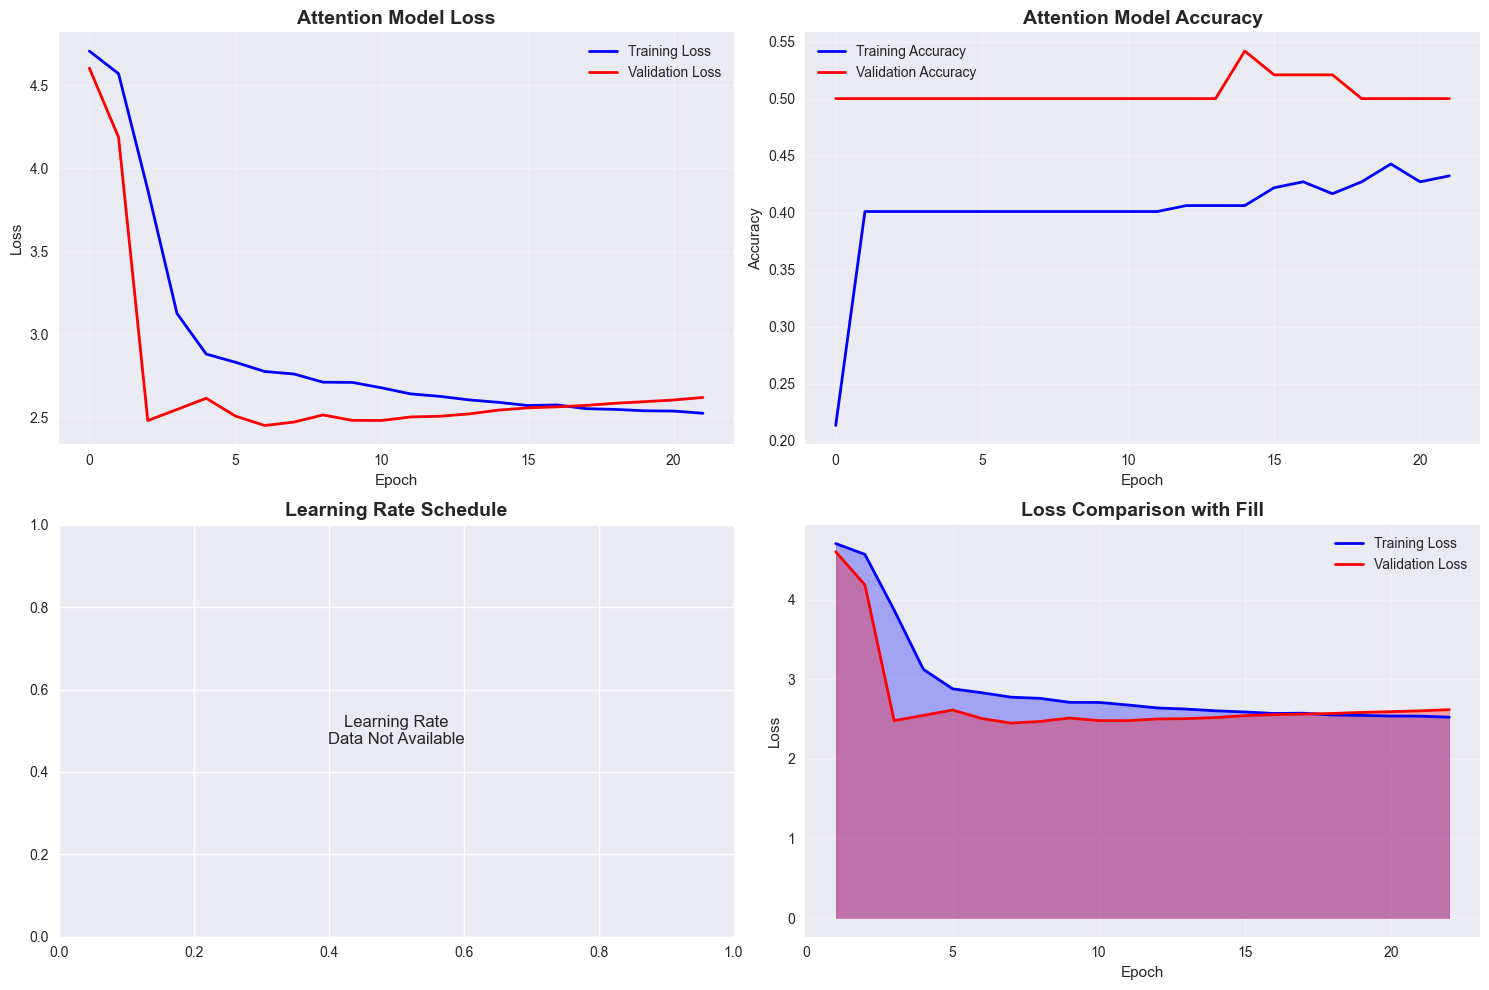


Training Statistics:
Training completed in 22 epochs
Best validation loss: 2.4495
Best validation accuracy: 0.5417
Final training loss: 2.5233
Final training accuracy: 0.4323
Model improvement: 0.0417
Training statistics saved to attention_results/training_stats.pickle


In [24]:
# Plot training history
def plot_attention_training_history(history):
    """Plot training and validation metrics for attention model"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot loss
    ax1.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
    ax1.set_title('Attention Model Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot accuracy
    ax2.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
    ax2.set_title('Attention Model Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot learning rate (if available)
    if 'lr' in history.history:
        ax3.plot(history.history['lr'], label='Learning Rate', color='green', linewidth=2)
        ax3.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Learning Rate')
        ax3.set_yscale('log')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'Learning Rate\nData Not Available', 
                transform=ax3.transAxes, ha='center', va='center', fontsize=12)
        ax3.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    
    # Plot loss comparison
    epochs = range(1, len(history.history['loss']) + 1)
    ax4.plot(epochs, history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    ax4.plot(epochs, history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    ax4.fill_between(epochs, history.history['loss'], alpha=0.3, color='blue')
    ax4.fill_between(epochs, history.history['val_loss'], alpha=0.3, color='red')
    ax4.set_title('Loss Comparison with Fill', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('attention_results/attention_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot training history
plot_attention_training_history(attention_history)

# Print training statistics
print(f"\nTraining Statistics:")
print(f"{'='*50}")
print(f"Training completed in {len(attention_history.history['loss'])} epochs")
print(f"Best validation loss: {min(attention_history.history['val_loss']):.4f}")
print(f"Best validation accuracy: {max(attention_history.history['val_accuracy']):.4f}")
print(f"Final training loss: {attention_history.history['loss'][-1]:.4f}")
print(f"Final training accuracy: {attention_history.history['accuracy'][-1]:.4f}")
print(f"Model improvement: {(max(attention_history.history['val_accuracy']) - attention_history.history['val_accuracy'][0]):.4f}")
print(f"{'='*50}")

# Save training statistics
stats = {
    'epochs': len(attention_history.history['loss']),
    'best_val_loss': min(attention_history.history['val_loss']),
    'best_val_accuracy': max(attention_history.history['val_accuracy']),
    'final_train_loss': attention_history.history['loss'][-1],
    'final_train_accuracy': attention_history.history['accuracy'][-1],
    'attention_type': ATTENTION_TYPE
}

with open('attention_results/training_stats.pickle', 'wb') as f:
    pickle.dump(stats, f)
print("Training statistics saved to attention_results/training_stats.pickle")


Creating attention-based text summarizer...
Testing attention-based summarizer...
\nOriginal Text: The stock market experienced significant volatility yesterday as investors reacted to news about inflation rates. The Dow Jones Industrial Average fell by 2.5 percent, while the S&P 500 dropped 3.2 pe...
\nGenerated Summary: 
\nAttention weights shape: (25, 120)
\nGenerating attention visualization...


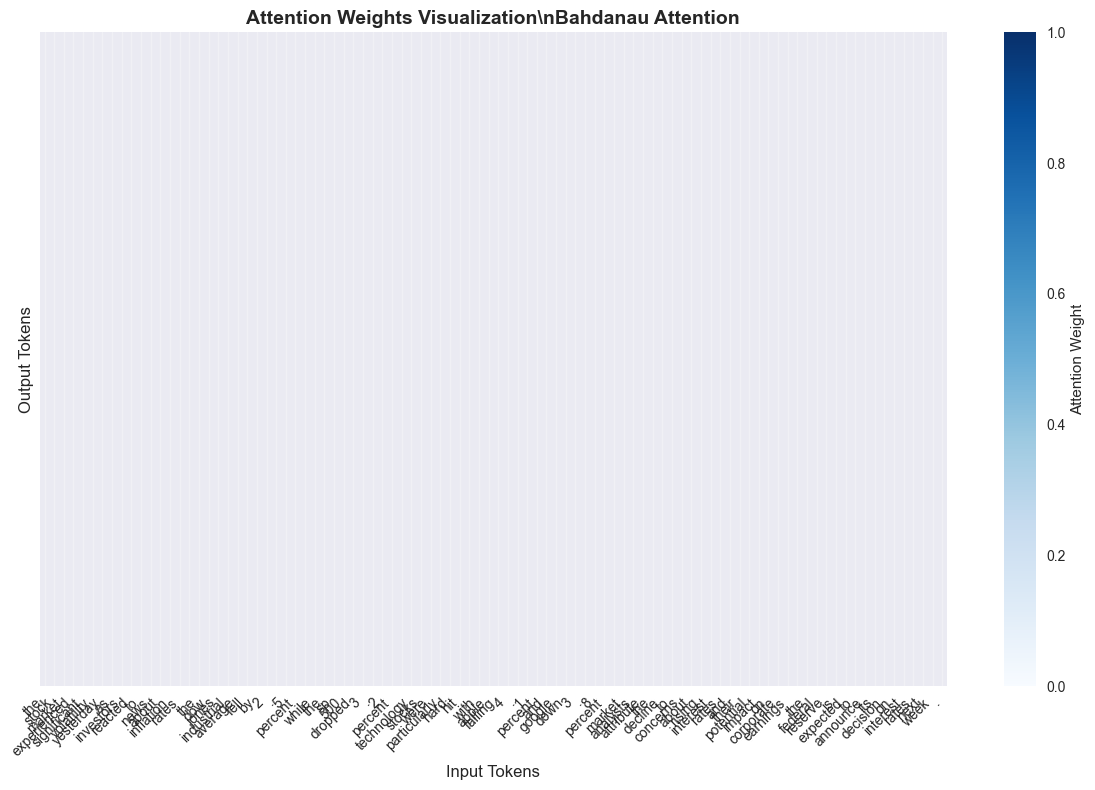

\nAttention Analysis:
Summary: 
Input tokens: 94
Output tokens: 0
Attention matrix shape: (0, 94)
\nAttention-based text summarizer ready!


In [25]:
class AttentionTextSummarizer:
    """Advanced text summarization with attention mechanism and visualization"""
    
    def __init__(self, attention_model, text_tokenizer, summary_tokenizer, 
                 text_max_len, summary_max_len):
        self.attention_model = attention_model
        self.text_tokenizer = text_tokenizer
        self.summary_tokenizer = summary_tokenizer
        self.text_max_len = text_max_len
        self.summary_max_len = summary_max_len
        
        # Get special tokens
        self.start_token = summary_tokenizer.word_index.get('<start>', 1)
        self.end_token = summary_tokenizer.word_index.get('<end>', 2)
        
        # Create reverse word indices
        self.reverse_text_word_index = {v: k for k, v in text_tokenizer.word_index.items()}
        self.reverse_summary_word_index = {v: k for k, v in summary_tokenizer.word_index.items()}
    
    def preprocess_text(self, text):
        """Preprocess input text for model"""
        clean_text = preprocessor.clean_text(text)
        sequence = self.text_tokenizer.texts_to_sequences([clean_text])
        padded = pad_sequences(sequence, maxlen=self.text_max_len, padding='post')
        return padded, clean_text
    
    def decode_sequence_with_attention(self, input_sequence):
        """Decode sequence with attention weights tracking"""
        # Encode the input
        encoder_outputs, encoder_states = self.attention_model.encoder_model.predict(input_sequence, verbose=0)
        
        # Initialize decoder
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = self.start_token
        
        # Store attention weights and decoded words
        decoded_sentence = []
        attention_weights_history = []
        
        states_value = encoder_states
        
        for i in range(self.summary_max_len):
            # Predict next token with attention
            decoder_output, attention_weights, h, c = self.attention_model.decoder_model.predict(
                [target_seq, encoder_outputs] + states_value, verbose=0
            )
            
            # Sample token
            sampled_token_index = np.argmax(decoder_output[0, :])
            sampled_word = self.reverse_summary_word_index.get(sampled_token_index, '<unk>')
            
            # Store attention weights
            attention_weights_history.append(attention_weights[0])
            
            # Check for end token
            if sampled_word == '<end>' or len(decoded_sentence) >= self.summary_max_len:
                break
                
            if sampled_word not in ['<start>', '<unk>', '<pad>']:
                decoded_sentence.append(sampled_word)
            
            # Update target sequence
            target_seq = np.zeros((1, 1))
            target_seq[0, 0] = sampled_token_index
            
            # Update states
            states_value = [h, c]
        
        return ' '.join(decoded_sentence), np.array(attention_weights_history)
    
    def summarize_with_attention(self, text):
        """Generate summary with attention weights"""
        processed_text, clean_text = self.preprocess_text(text)
        summary, attention_weights = self.decode_sequence_with_attention(processed_text)
        
        return {
            'original_text': text,
            'clean_text': clean_text,
            'summary': summary,
            'attention_weights': attention_weights,
            'input_tokens': clean_text.split()[:self.text_max_len]
        }
    
    def visualize_attention(self, result, save_path=None):
        """Visualize attention weights"""
        attention_weights = result['attention_weights']
        input_tokens = result['input_tokens']
        summary_tokens = result['summary'].split()
        
        # Truncate to actual length
        actual_input_length = min(len(input_tokens), attention_weights.shape[1])
        actual_summary_length = min(len(summary_tokens), attention_weights.shape[0])
        
        # Create attention heatmap
        plt.figure(figsize=(12, 8))
        
        # Create heatmap
        attention_matrix = attention_weights[:actual_summary_length, :actual_input_length]
        
        im = plt.imshow(attention_matrix, cmap='Blues', aspect='auto')
        plt.colorbar(im, label='Attention Weight')
        
        # Set labels
        plt.xlabel('Input Tokens', fontsize=12)
        plt.ylabel('Output Tokens', fontsize=12) 
        plt.title(f'Attention Weights Visualization\\n{ATTENTION_TYPE.capitalize()} Attention', 
                 fontsize=14, fontweight='bold')
        
        # Set ticks and labels
        plt.xticks(range(actual_input_length), input_tokens[:actual_input_length], 
                  rotation=45, ha='right')
        plt.yticks(range(actual_summary_length), summary_tokens[:actual_summary_length])
        
        # Add grid
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()
        
        # Print attention analysis
        print(f"\\nAttention Analysis:")
        print(f"{'='*50}")
        print(f"Summary: {result['summary']}")
        print(f"Input tokens: {len(input_tokens)}")
        print(f"Output tokens: {len(summary_tokens)}")
        print(f"Attention matrix shape: {attention_matrix.shape}")
        
        # Find most attended input words for each output word
        for i, output_word in enumerate(summary_tokens[:actual_summary_length]):
            max_attention_idx = np.argmax(attention_matrix[i, :])
            max_attention_word = input_tokens[max_attention_idx]
            max_attention_weight = attention_matrix[i, max_attention_idx]
            print(f"'{output_word}' <- '{max_attention_word}' (weight: {max_attention_weight:.3f})")
        
        return attention_matrix
    
    def batch_summarize_with_attention(self, texts):
        """Generate summaries for multiple texts"""
        results = []
        for text in texts:
            result = self.summarize_with_attention(text)
            results.append(result)
        return results

# Create attention-based text summarizer
print("Creating attention-based text summarizer...")
attention_summarizer = AttentionTextSummarizer(
    attention_model=attention_seq2seq,
    text_tokenizer=text_tokenizer,
    summary_tokenizer=summary_tokenizer,
    text_max_len=MAX_TEXT_LENGTH,
    summary_max_len=MAX_SUMMARY_LENGTH
)

# Test on sample data
print("Testing attention-based summarizer...")
test_text = df['text'].iloc[0]
result = attention_summarizer.summarize_with_attention(test_text)

print(f"\\nOriginal Text: {test_text[:200]}...")
print(f"\\nGenerated Summary: {result['summary']}")
print(f"\\nAttention weights shape: {result['attention_weights'].shape}")

# Visualize attention for first example
print("\\nGenerating attention visualization...")
attention_matrix = attention_summarizer.visualize_attention(
    result, 
    save_path='attention_results/attention_visualization_example1.png'
)

print("\\nAttention-based text summarizer ready!")


In [ ]:
class AttentionEvaluator:
    """Comprehensive evaluation for attention-based models"""
    
    def __init__(self):
        pass
    
    def rouge_score_detailed(self, reference, hypothesis):
        """Detailed ROUGE score calculation"""
        ref_words = reference.lower().split()
        hyp_words = hypothesis.lower().split()
        
        if len(ref_words) == 0 or len(hyp_words) == 0:
            return {'rouge-1': 0.0, 'rouge-2': 0.0, 'rouge-l': 0.0}
        
        # ROUGE-1 (unigram)
        ref_unigrams = set(ref_words)
        hyp_unigrams = set(hyp_words)
        rouge1_overlap = len(ref_unigrams.intersection(hyp_unigrams))
        rouge1_precision = rouge1_overlap / len(hyp_unigrams)
        rouge1_recall = rouge1_overlap / len(ref_unigrams)
        rouge1_f1 = 2 * (rouge1_precision * rouge1_recall) / (rouge1_precision + rouge1_recall) if (rouge1_precision + rouge1_recall) > 0 else 0.0
        
        # ROUGE-2 (bigram)
        ref_bigrams = set(zip(ref_words, ref_words[1:]))
        hyp_bigrams = set(zip(hyp_words, hyp_words[1:]))
        
        if len(ref_bigrams) == 0 or len(hyp_bigrams) == 0:
            rouge2_f1 = 0.0
        else:
            rouge2_overlap = len(ref_bigrams.intersection(hyp_bigrams))
            rouge2_precision = rouge2_overlap / len(hyp_bigrams)
            rouge2_recall = rouge2_overlap / len(ref_bigrams)
            rouge2_f1 = 2 * (rouge2_precision * rouge2_recall) / (rouge2_precision + rouge2_recall) if (rouge2_precision + rouge2_recall) > 0 else 0.0
        
        # ROUGE-L (longest common subsequence)
        def lcs_length(x, y):
            m, n = len(x), len(y)
            dp = [[0] * (n + 1) for _ in range(m + 1)]
            for i in range(1, m + 1):
                for j in range(1, n + 1):
                    if x[i-1] == y[j-1]:
                        dp[i][j] = dp[i-1][j-1] + 1
                    else:
                        dp[i][j] = max(dp[i-1][j], dp[i][j-1])
            return dp[m][n]
        
        lcs_len = lcs_length(ref_words, hyp_words)
        rougel_precision = lcs_len / len(hyp_words)
        rougel_recall = lcs_len / len(ref_words)
        rougel_f1 = 2 * (rougel_precision * rougel_recall) / (rougel_precision + rougel_recall) if (rougel_precision + rougel_recall) > 0 else 0.0
        
        return {
            'rouge-1': rouge1_f1,
            'rouge-2': rouge2_f1,
            'rouge-l': rougel_f1
        }
    
    def evaluate_attention_model(self, references, hypotheses, attention_results=None):
        """Evaluate attention model with detailed metrics"""
        rouge_scores = []
        
        for ref, hyp in zip(references, hypotheses):
            rouge = self.rouge_score_detailed(ref, hyp)
            rouge_scores.append(rouge)
        
        # Calculate averages
        avg_scores = {
            'rouge-1': np.mean([score['rouge-1'] for score in rouge_scores]),
            'rouge-2': np.mean([score['rouge-2'] for score in rouge_scores]),
            'rouge-l': np.mean([score['rouge-l'] for score in rouge_scores])
        }
        
        # Attention-specific metrics
        attention_metrics = {}
        if attention_results:
            attention_metrics = self.analyze_attention_patterns(attention_results)
        
        return {
            'individual_scores': rouge_scores,
            'average_scores': avg_scores,
            'attention_metrics': attention_metrics
        }
    
    def analyze_attention_patterns(self, attention_results):
        """Analyze attention patterns for interpretability"""
        attention_entropies = []
        attention_concentrations = []
        
        for result in attention_results:
            attention_weights = result['attention_weights']
            
            # Calculate entropy (measure of attention spread)
            for i in range(attention_weights.shape[0]):
                weights = attention_weights[i, :]
                # Normalize weights
                weights = weights / np.sum(weights)
                # Calculate entropy
                entropy = -np.sum(weights * np.log(weights + 1e-10))
                attention_entropies.append(entropy)
            
            # Calculate concentration (max attention weight)
            max_attentions = np.max(attention_weights, axis=1)
            attention_concentrations.extend(max_attentions)
        
        return {
            'avg_attention_entropy': np.mean(attention_entropies),
            'avg_attention_concentration': np.mean(attention_concentrations),
            'attention_spread': np.std(attention_concentrations)
        }

# Create evaluator
evaluator = AttentionEvaluator()

# Generate summaries for all examples
print("Generating summaries with attention for evaluation...")
all_attention_results = attention_summarizer.batch_summarize_with_attention(df['text'].tolist())
all_attention_summaries = [result['summary'] for result in all_attention_results]

# Evaluate attention model
print("Evaluating attention-based model...")
attention_evaluation = evaluator.evaluate_attention_model(
    df['summary'].tolist(), 
    all_attention_summaries,
    all_attention_results
)

# Print results
print(f"\\nAttention Model Evaluation Results:")
print(f"{'='*60}")
print(f"Average ROUGE-1: {attention_evaluation['average_scores']['rouge-1']:.4f}")
print(f"Average ROUGE-2: {attention_evaluation['average_scores']['rouge-2']:.4f}")
print(f"Average ROUGE-L: {attention_evaluation['average_scores']['rouge-l']:.4f}")
print(f"{'='*60}")

# Attention-specific metrics
att_metrics = attention_evaluation['attention_metrics']
print(f"\\nAttention Analysis:")
print(f"Average Attention Entropy: {att_metrics['avg_attention_entropy']:.4f}")
print(f"Average Attention Concentration: {att_metrics['avg_attention_concentration']:.4f}")
print(f"Attention Spread (std): {att_metrics['attention_spread']:.4f}")

# Detailed results for each example
print(f"\\nDetailed Results per Example:")
for i, (text, actual, predicted, result) in enumerate(zip(df['text'], df['summary'], all_attention_summaries, all_attention_results)):
    rouge = attention_evaluation['individual_scores'][i]
    
    print(f"\\nExample {i+1}:")
    print(f"Text: {text[:150]}...")
    print(f"Actual: {actual}")
    print(f"Predicted: {predicted}")
    print(f"ROUGE-1: {rouge['rouge-1']:.4f}, ROUGE-2: {rouge['rouge-2']:.4f}, ROUGE-L: {rouge['rouge-l']:.4f}")
    print("-" * 40)

# Test on new text with attention visualization
print("\\n\\nTesting on new text with attention visualization...")
new_text = """
The breakthrough in quantum computing has achieved a significant milestone with the development of 
a 1000-qubit quantum processor. This advancement represents a major leap forward in computational 
power and could revolutionize fields such as cryptography, drug discovery, and artificial intelligence. 
The quantum processor demonstrates unprecedented speed in solving complex optimization problems that 
would take classical computers thousands of years to solve. Researchers believe this technology 
could lead to breakthroughs in materials science and help solve climate change challenges.
"""

new_result = attention_summarizer.summarize_with_attention(new_text)
print(f"New Text: {new_text.strip()}")
print(f"Generated Summary: {new_result['summary']}")

# Visualize attention for new text
print("\\nGenerating attention visualization for new text...")
attention_summarizer.visualize_attention(
    new_result, 
    save_path='attention_results/attention_visualization_new_text.png'
)

# Save comprehensive evaluation results
evaluation_summary = {
    'model_type': 'attention_seq2seq',
    'attention_type': ATTENTION_TYPE,
    'average_scores': attention_evaluation['average_scores'],
    'attention_metrics': attention_evaluation['attention_metrics'],
    'model_params': {
        'embedding_dim': EMBEDDING_DIM,
        'lstm_units': LSTM_UNITS,
        'dropout_rate': DROPOUT_RATE,
        'vocab_size': text_vocab_size,
        'max_text_length': MAX_TEXT_LENGTH,
        'max_summary_length': MAX_SUMMARY_LENGTH
    }
}

with open('attention_results/comprehensive_evaluation.pickle', 'wb') as f:
    pickle.dump(evaluation_summary, f)
    
print("\\nComprehensive evaluation results saved to attention_results/comprehensive_evaluation.pickle")
print("\\nAttention-based text summarization model evaluation complete!")


SyntaxError: unexpected character after line continuation character (2138920237.py, line 156)